In [3]:
import pandas as pd
df1 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df.csv")
pd.DataFrame(df1)

,Reviews for Samsung Galaxy Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,It's much better than watch ultra 2. Value for...,25-34,M,"Tirunelveli, Tamil Nadu",Working Professional,October,2021,Q4
1,Value for money ? No.\nQuality: built quality ...,35-44,M,"Bengaluru, Karnataka",Working Professional,April,2020,Q2
2,Just one word.......awesome. go for it,18-24,M,"Navi Mumbai, Maharashtra",Student,April,2020,Q2
3,"Android Users other than that of Samsung, you ...",55 and above,M,"New Delhi, Delhi",Retired,September,2020,Q3
4,Exalent watch,55 and above,F,"Devanahalli, Karnataka",Retired,May,2020,Q2
...,...,...,...,...,...,...,...,...
411,Best smartwatch in this time. Many more option...,25-34,F,"Patna, Bihar",Homemaker,March,2024,Q1
412,Not bad,18-24,F,"Kozhikode, Kerala",Working Professional,November,2020,Q4
413,Nice product with lot of features but battery ...,55 and above,F,"Navi Mumbai, Maharashtra",Homemaker,May,2021,Q2
414,Samsung Galaxy Watch 4 Classic LTE: A Comprehe...,25-34,M,"Lucknow, Uttar Pradesh",Freelancer,October,2023,Q4


In [9]:
from textblob import TextBlob

df1.columns

Index(['Reviews for Samsung Galaxy Watch', 'Age', 'Gender', 'Location',
       'Occupation', 'Month', 'Year', 'Quarter'],
      dtype='object')

In [10]:
df1['Gender'] = df1['Gender'].str.strip()
df1['Gender'].unique()

array(['M', 'F'], dtype=object)

In [27]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df1.columns = df1.columns.str.strip()
review_column = "Reviews for Samsung Galaxy Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df1[['Polarity', 'Sentiment']] = df1[review_column].apply(analyze_sentiment)
print(df1.head())


                    Reviews for Samsung Galaxy Watch           Age Gender  \
0  It's much better than watch ultra 2. Value for...         25-34      M   
1  Value for money ? No.\nQuality: built quality ...         35-44      M   
2             Just one word.......awesome. go for it         18-24      M   
3  Android Users other than that of Samsung, you ...  55 and above      M   
4                                      Exalent watch  55 and above      F   

                    Location            Occupation      Month  Year Quarter  \
0    Tirunelveli, Tamil Nadu  Working Professional    October  2021      Q4   
1       Bengaluru, Karnataka  Working Professional      April  2020      Q2   
2   Navi Mumbai, Maharashtra               Student      April  2020      Q2   
3           New Delhi, Delhi               Retired  September  2020      Q3   
4     Devanahalli, Karnataka               Retired        May  2020      Q2   

   Polarity Sentiment  Sentiment Score        state  
0  0.500

In [33]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df1['state'] = df1['Location'].astype(str).apply(extract_state)
df1

,Reviews for Samsung Galaxy Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,Sentiment Score,state
0,It's much better than watch ultra 2. Value for...,25-34,M,"Tirunelveli, Tamil Nadu",Working Professional,October,2021,Q4,0.500000,Positive,1.0,Tamil Nadu
1,Value for money ? No.\nQuality: built quality ...,35-44,M,"Bengaluru, Karnataka",Working Professional,April,2020,Q2,0.036296,Positive,1.0,Karnataka
2,Just one word.......awesome. go for it,18-24,M,"Navi Mumbai, Maharashtra",Student,April,2020,Q2,0.000000,Neutral,0.5,Maharashtra
3,"Android Users other than that of Samsung, you ...",55 and above,M,"New Delhi, Delhi",Retired,September,2020,Q3,0.080556,Positive,1.0,Delhi
4,Exalent watch,55 and above,F,"Devanahalli, Karnataka",Retired,May,2020,Q2,0.000000,Neutral,0.5,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...,...
411,Best smartwatch in this time. Many more option...,25-34,F,"Patna, Bihar",Homemaker,March,2024,Q1,0.633333,Positive,1.0,Bihar
412,Not bad,18-24,F,"Kozhikode, Kerala",Working Professional,November,2020,Q4,0.350000,Positive,1.0,Kerala
413,Nice product with lot of features but battery ...,55 and above,F,"Navi Mumbai, Maharashtra",Homemaker,May,2021,Q2,0.216667,Positive,1.0,Maharashtra
414,Samsung Galaxy Watch 4 Classic LTE: A Comprehe...,25-34,M,"Lucknow, Uttar Pradesh",Freelancer,October,2023,Q4,0.179167,Positive,1.0,Uttar Pradesh


<Figure size 5000x800 with 0 Axes>

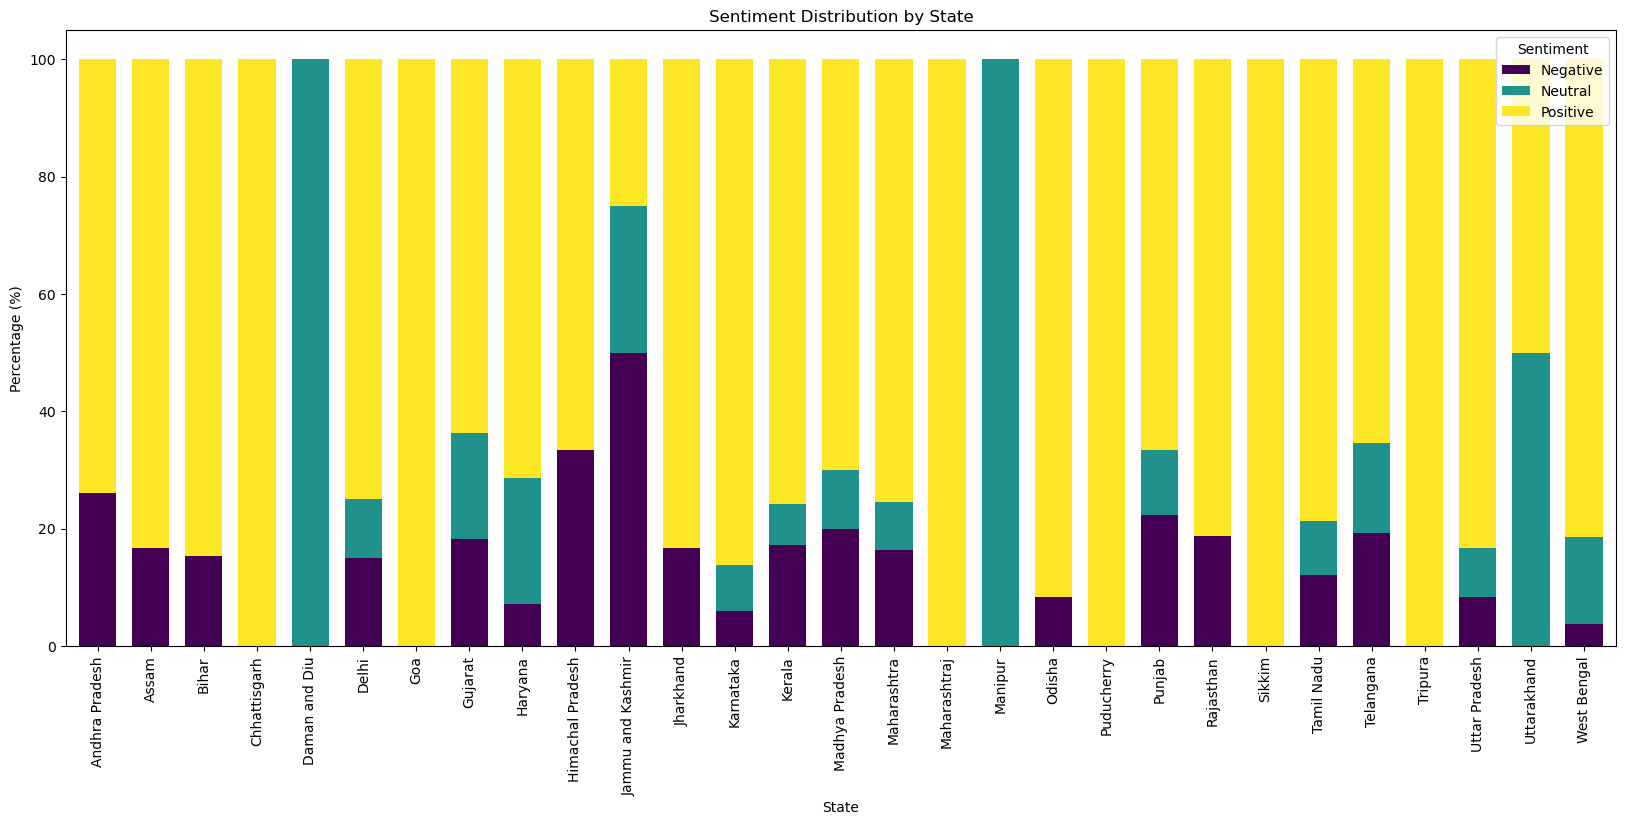

In [99]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df1.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
plt.figure(figsize=(50, 8))
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_by_state(Samsung)[Sales Analysis].png")
plt.show()

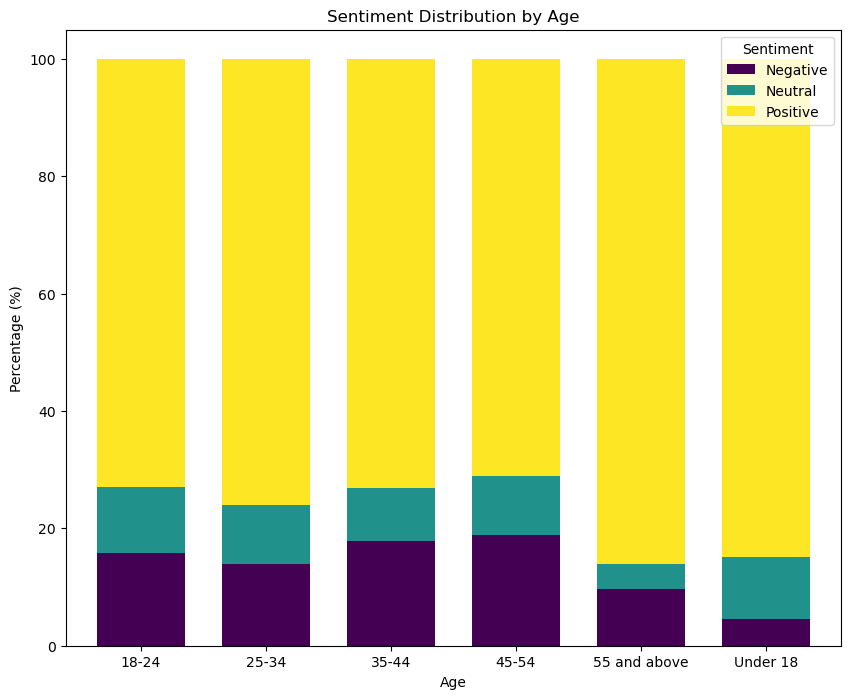

In [119]:
age_group_sentiment = df1.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_age(Samsung)[Sales Analysis].png")
plt.show()


<Figure size 1000x800 with 0 Axes>

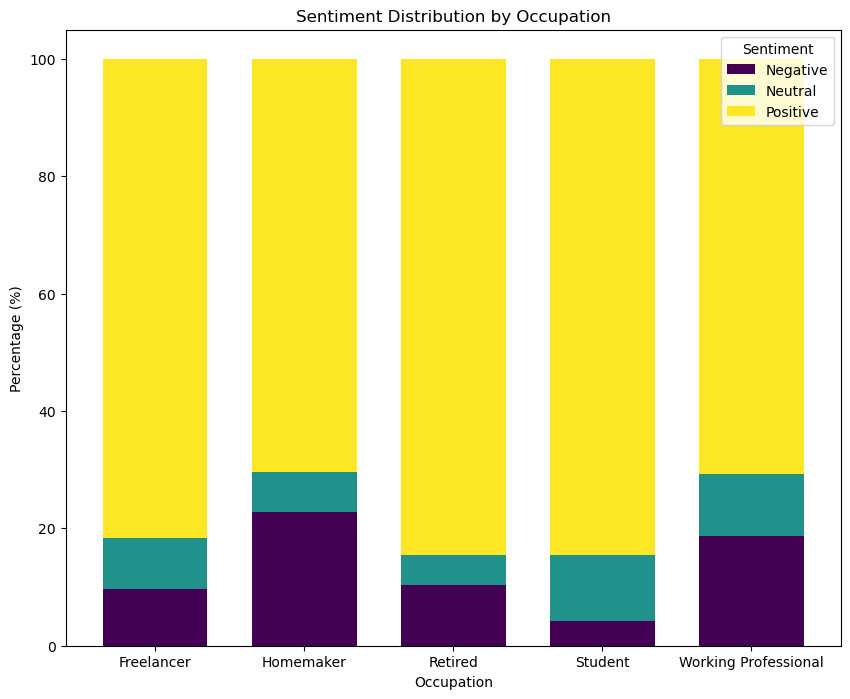

In [123]:
occupation_sentiment = df1.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_occupation(Samsung)[Sales Analysis].png")
plt.show()


<Figure size 500x500 with 0 Axes>

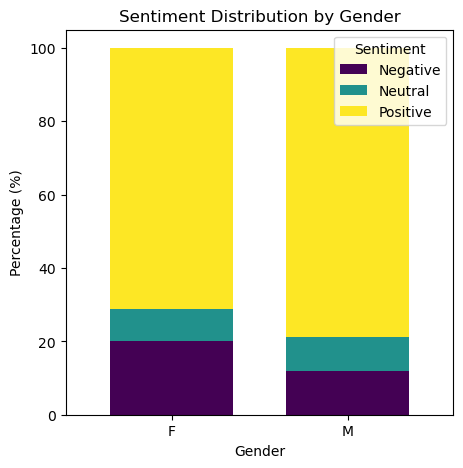

In [125]:
gender_sentiment = df1.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_gender(samsung)[Sales Analysis].png")
plt.show()


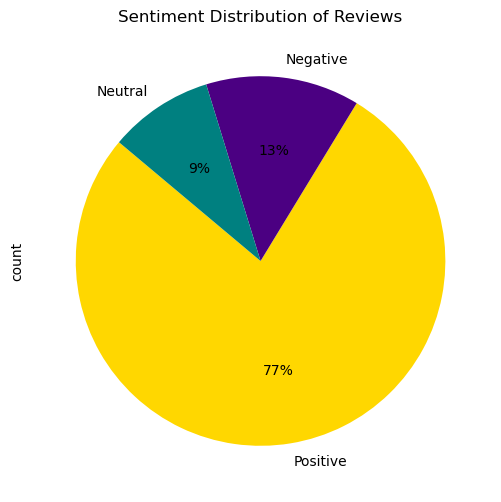

In [129]:
sentiment_counts = df1["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(samsung)[Sales Analysis].png")
plt.show()

In [131]:
df2 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df2.csv")
pd.DataFrame(df2)

,Reviews for Apple Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,The product is a beast ! Feels premium and is ...,25-34,F,"Kalyan, Maharashtra",Homemaker,June,2021,Q2
1,Apple watch Ultra 2 is a beast when it comes t...,55 and above,M,"Kanpur, Uttar Pradesh",Retired,July,2024,Q3
2,Very good product nice Apple Watch thanks flip...,25-34,M,"Chennai, Tamil Nadu",Working Professional,June,2021,Q2
3,Very nice product,35-44,M,"Ahmadnagar, Maharashtra",Working Professional,May,2023,Q2
4,"Nothing to say more , its just a beast in its ...",45-54,F,"West Godavari, Andhra Pradesh",Homemaker,January,2023,Q1
...,...,...,...,...,...,...,...,...
326,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,October,2024,Q4
327,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,November,2020,Q4
328,Awesome Watch,55 and above,F,"Ahmedabad, Gujarat",Retired,November,2023,Q4
329,Looks premium and special,25-34,M,"Bengaluru, Karnataka",Working Professional,August,2021,Q3


In [133]:
from textblob import TextBlob

df2.columns

Index(['Reviews for Apple Watch ', 'Age', 'Gender', 'Location',
       '        Occupation', 'Month', 'Year', 'Quarter'],
      dtype='object')

In [135]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df2.columns = df2.columns.str.strip()
review_column = "Reviews for Apple Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df2[['Polarity', 'Sentiment']] = df2[review_column].apply(analyze_sentiment)
print(df2.head())


                             Reviews for Apple Watch           Age Gender  \
0  The product is a beast ! Feels premium and is ...         25-34      F   
1  Apple watch Ultra 2 is a beast when it comes t...  55 and above      M   
2  Very good product nice Apple Watch thanks flip...         25-34      M   
3                                  Very nice product         35-44      M   
4  Nothing to say more , its just a beast in its ...         45-54      F   

                         Location            Occupation    Month  Year  \
0             Kalyan, Maharashtra             Homemaker     June  2021   
1           Kanpur, Uttar Pradesh               Retired     July  2024   
2             Chennai, Tamil Nadu  Working Professional     June  2021   
3         Ahmadnagar, Maharashtra  Working Professional      May  2023   
4   West Godavari, Andhra Pradesh             Homemaker  January  2023   

  Quarter  Polarity Sentiment  
0      Q2  0.000000   Neutral  
1      Q3  0.250000  Positiv

In [137]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df2['state'] = df2['Location'].astype(str).apply(extract_state)
df2

,Reviews for Apple Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,The product is a beast ! Feels premium and is ...,25-34,F,"Kalyan, Maharashtra",Homemaker,June,2021,Q2,0.000000,Neutral,Maharashtra
1,Apple watch Ultra 2 is a beast when it comes t...,55 and above,M,"Kanpur, Uttar Pradesh",Retired,July,2024,Q3,0.250000,Positive,Uttar Pradesh
2,Very good product nice Apple Watch thanks flip...,25-34,M,"Chennai, Tamil Nadu",Working Professional,June,2021,Q2,0.570000,Positive,Tamil Nadu
3,Very nice product,35-44,M,"Ahmadnagar, Maharashtra",Working Professional,May,2023,Q2,0.780000,Positive,Maharashtra
4,"Nothing to say more , its just a beast in its ...",45-54,F,"West Godavari, Andhra Pradesh",Homemaker,January,2023,Q1,0.376429,Positive,Andhra Pradesh
...,...,...,...,...,...,...,...,...,...,...,...
326,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,October,2024,Q4,0.420357,Positive,Uttar Pradesh
327,I ordered watches for all my family members..\...,35-44,M,"Noida, Uttar Pradesh",Working Professional,November,2020,Q4,0.420357,Positive,Uttar Pradesh
328,Awesome Watch,55 and above,F,"Ahmedabad, Gujarat",Retired,November,2023,Q4,1.000000,Positive,Gujarat
329,Looks premium and special,25-34,M,"Bengaluru, Karnataka",Working Professional,August,2021,Q3,0.357143,Positive,Karnataka


<Figure size 5000x800 with 0 Axes>

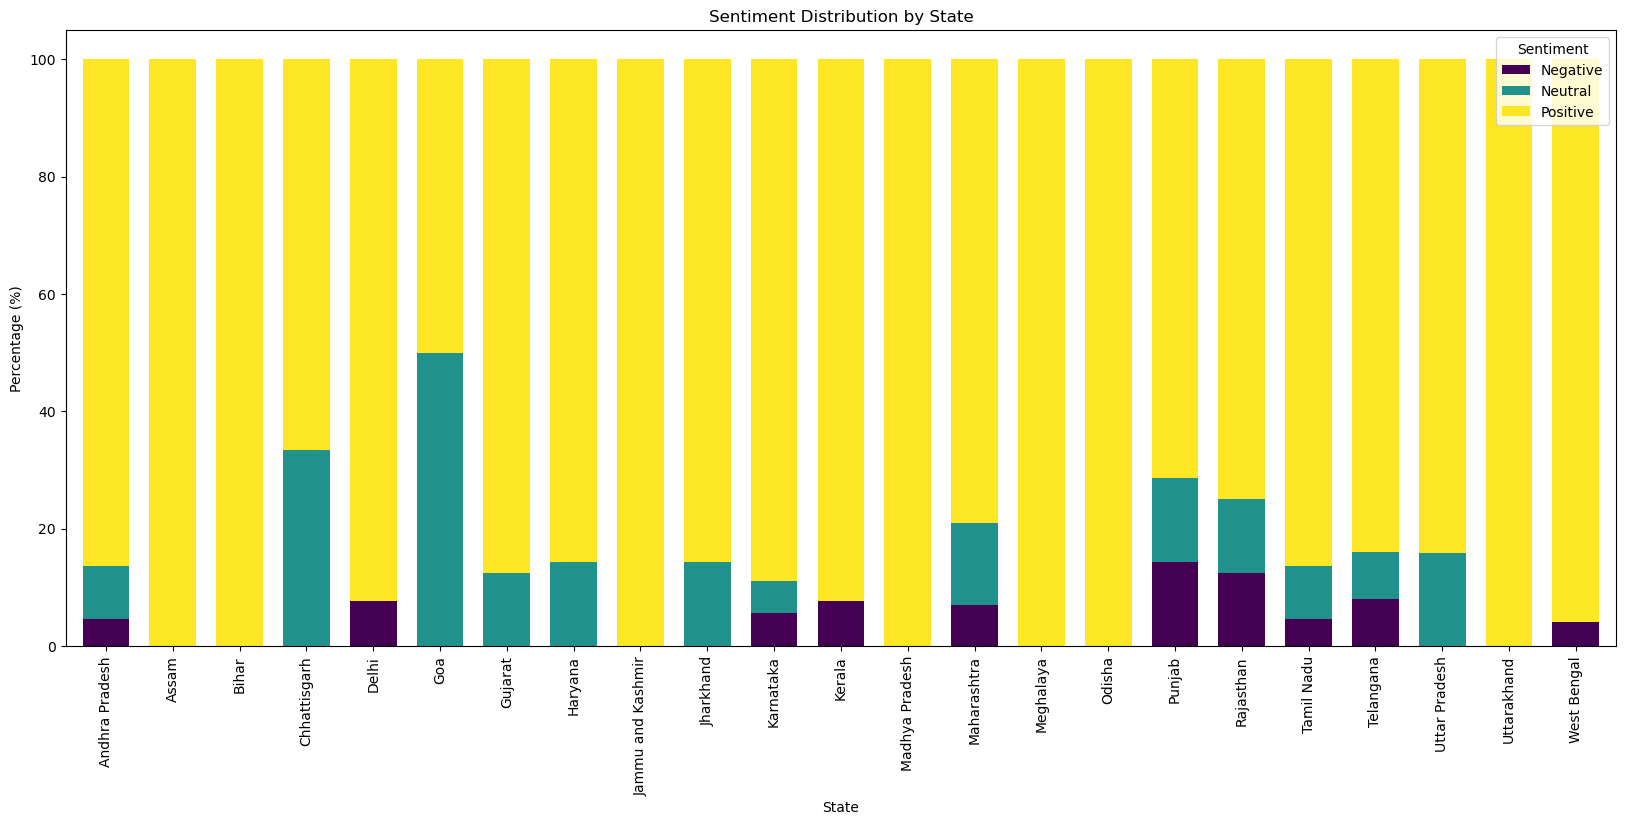

In [145]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df2.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
plt.figure(figsize=(50, 8))
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_by_state(Apple)[Sales Analysis].png")
plt.show()

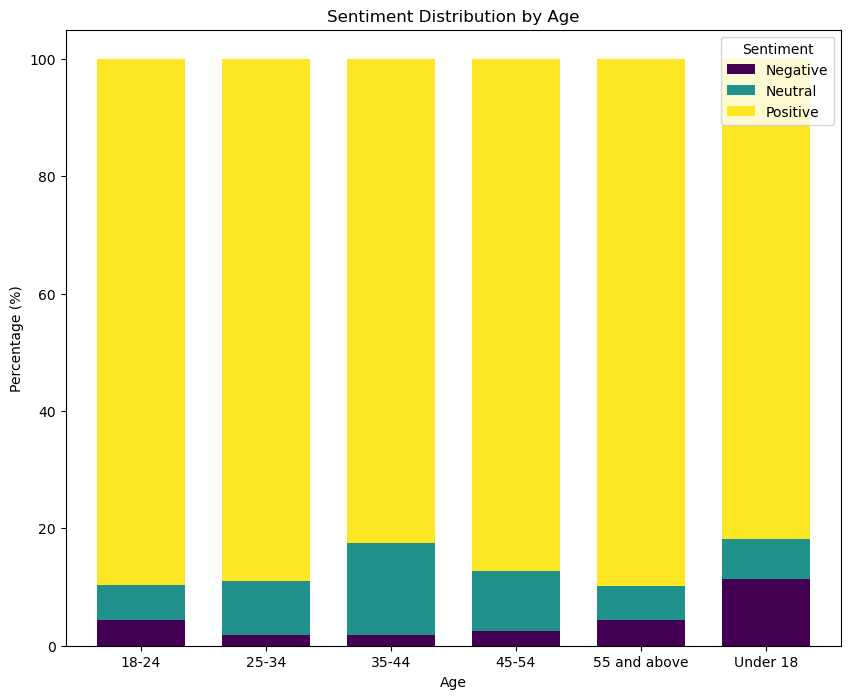

In [147]:
age_group_sentiment = df2.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_age(Apple)[Sales Analysis].png")
plt.show()


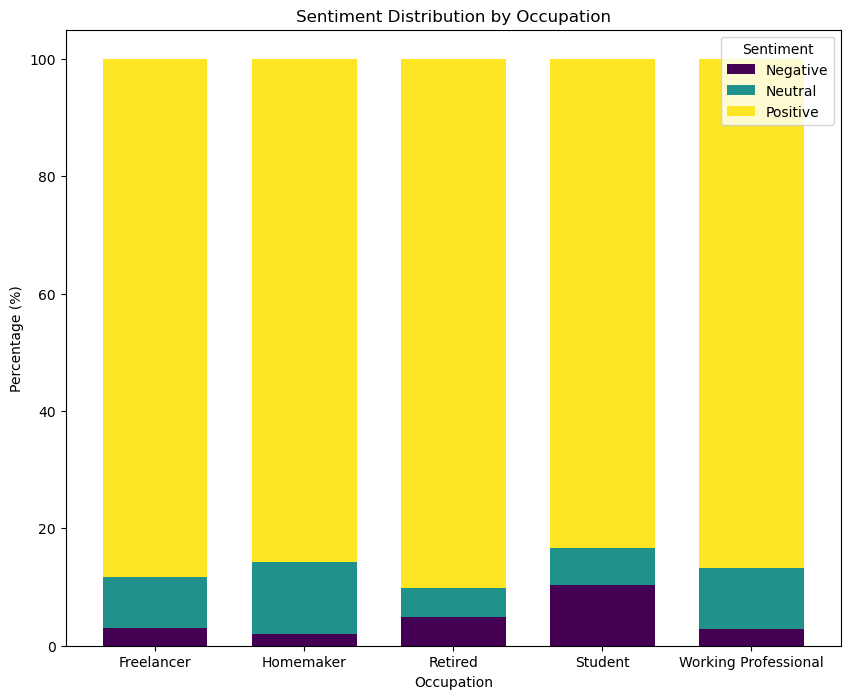

In [149]:
occupation_sentiment = df2.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_occupation(Apple)[Sales Analysis].png")
plt.show()


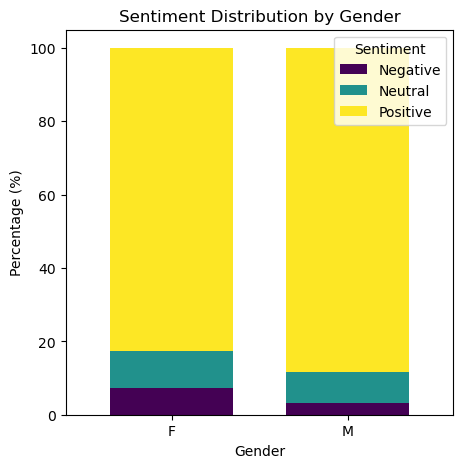

In [151]:
gender_sentiment = df2.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_gender(Apple)[Sales Analysis].png")
plt.show()


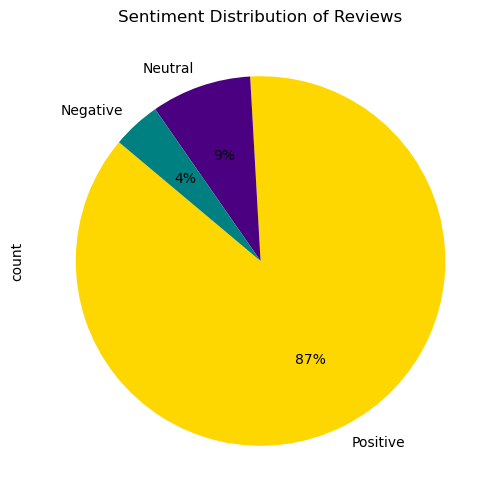

In [153]:
sentiment_counts = df2["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Apple)[Sales Analysis].png")
plt.show()

In [155]:
df5 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df5.csv")
pd.DataFrame(df5)

,Reviews for Redmi Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Watch is big in size but looks professional. B...,35-44,F,"Bhubaneswar, Odisha",Homemaker,December,2022,Q4
1,Best smartwatch in this budget with calling an...,45-54,M,"Ghaziabad, Uttar Pradesh",Freelancer,May,2022,Q2
2,The size is too big and it can be slim too. If...,35-44,M,"Madurai, Tamil Nadu",Freelancer,January,2020,Q1
3,Everything is perfect.\nBest of budget smartwa...,18-24,F,"Burdwan, West Bengal",Working Professional,April,2022,Q2
4,Battery back up is superb\nConnectivity is als...,35-44,M,"Gandhinagar, Gujarat",Working Professional,September,2020,Q3
...,...,...,...,...,...,...,...,...
276,Such a wonderful watch!,18-24,F,"Prayagraj, Uttar Pradesh",Working Professional,October,2021,Q4
277,Nc,18-24,M,"Kendrapara, Odisha",Working Professional,July,2020,Q3
278,It is a nice working design with a good lookin...,45-54,F,"Srinagar, Jammu and Kashmir",Homemaker,March,2024,Q1
279,"I use to measure heart beats, distance I walked.",35-44,F,"Mumbai, Maharashtra",Working Professional,February,2020,Q1


In [159]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df5.columns = df5.columns.str.strip()
review_column = "Reviews for Redmi Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df5[['Polarity', 'Sentiment']] = df5[review_column].apply(analyze_sentiment)
print(df5.head())


                             Reviews for Redmi Watch    Age Gender  \
0  Watch is big in size but looks professional. B...  35-44      F   
1  Best smartwatch in this budget with calling an...  45-54      M   
2  The size is too big and it can be slim too. If...  35-44      M   
3  Everything is perfect.\nBest of budget smartwa...  18-24      F   
4  Battery back up is superb\nConnectivity is als...  35-44      M   

                    Location            Occupation      Month  Year Quarter  \
0        Bhubaneswar, Odisha             Homemaker   December  2022      Q4   
1   Ghaziabad, Uttar Pradesh            Freelancer        May  2022      Q2   
2        Madurai, Tamil Nadu            Freelancer    January  2020      Q1   
3       Burdwan, West Bengal  Working Professional      April  2022      Q2   
4      Gandhinagar, Gujarat   Working Professional  September  2020      Q3   

   Polarity Sentiment  
0  0.260000  Positive  
1  0.315741  Positive  
2 -0.041667  Negative  
3  1.000

In [161]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df5['state'] = df5['Location'].astype(str).apply(extract_state)
df5

,Reviews for Redmi Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Watch is big in size but looks professional. B...,35-44,F,"Bhubaneswar, Odisha",Homemaker,December,2022,Q4,0.260000,Positive,Odisha
1,Best smartwatch in this budget with calling an...,45-54,M,"Ghaziabad, Uttar Pradesh",Freelancer,May,2022,Q2,0.315741,Positive,Uttar Pradesh
2,The size is too big and it can be slim too. If...,35-44,M,"Madurai, Tamil Nadu",Freelancer,January,2020,Q1,-0.041667,Negative,Tamil Nadu
3,Everything is perfect.\nBest of budget smartwa...,18-24,F,"Burdwan, West Bengal",Working Professional,April,2022,Q2,1.000000,Positive,West Bengal
4,Battery back up is superb\nConnectivity is als...,35-44,M,"Gandhinagar, Gujarat",Working Professional,September,2020,Q3,0.438492,Positive,Gujarat
...,...,...,...,...,...,...,...,...,...,...,...
276,Such a wonderful watch!,18-24,F,"Prayagraj, Uttar Pradesh",Working Professional,October,2021,Q4,0.500000,Positive,Uttar Pradesh
277,Nc,18-24,M,"Kendrapara, Odisha",Working Professional,July,2020,Q3,0.000000,Neutral,Odisha
278,It is a nice working design with a good lookin...,45-54,F,"Srinagar, Jammu and Kashmir",Homemaker,March,2024,Q1,0.477857,Positive,Jammu and Kashmir
279,"I use to measure heart beats, distance I walked.",35-44,F,"Mumbai, Maharashtra",Working Professional,February,2020,Q1,0.000000,Neutral,Maharashtra


In [167]:
df5['state'].unique()
df5 = df5[df5['state'] != 'Maharshtra']

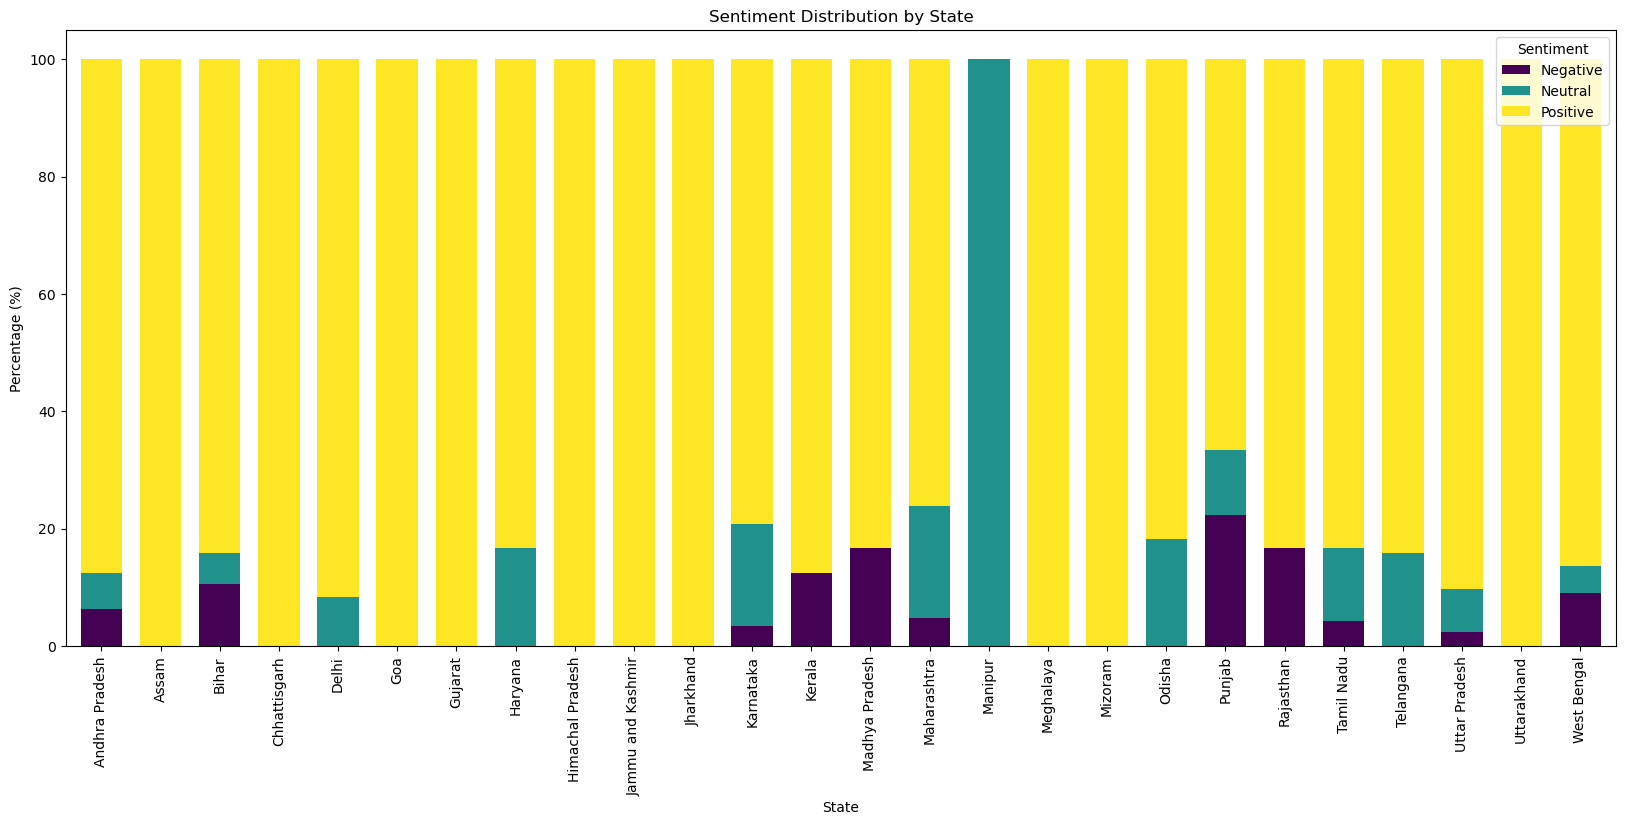

In [169]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df5.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_by_state(Redmi)[Sales Analysis].png")
plt.show()

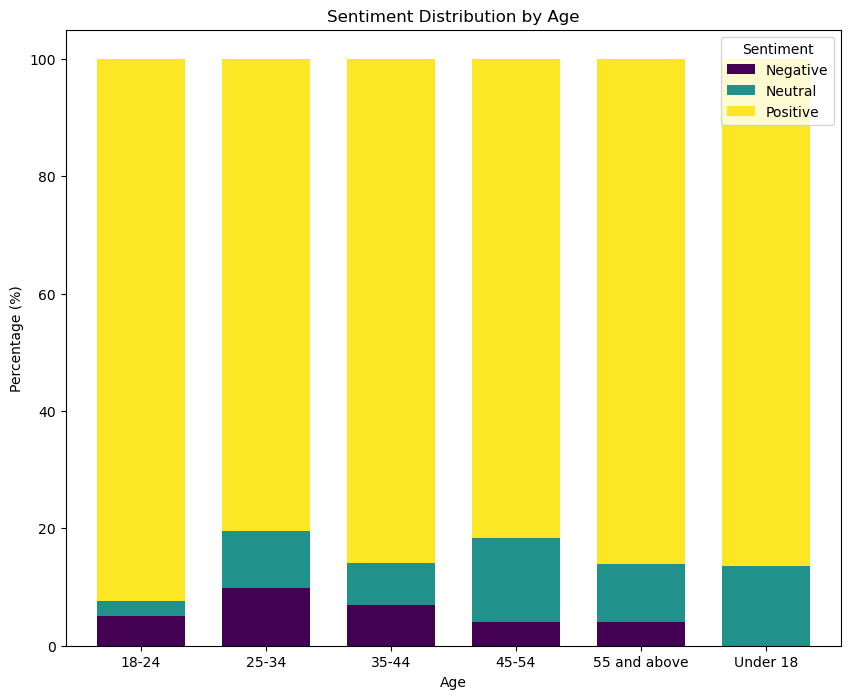

In [171]:
age_group_sentiment = df5.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_age(Redmi)[Sales Analysis].png")
plt.show()


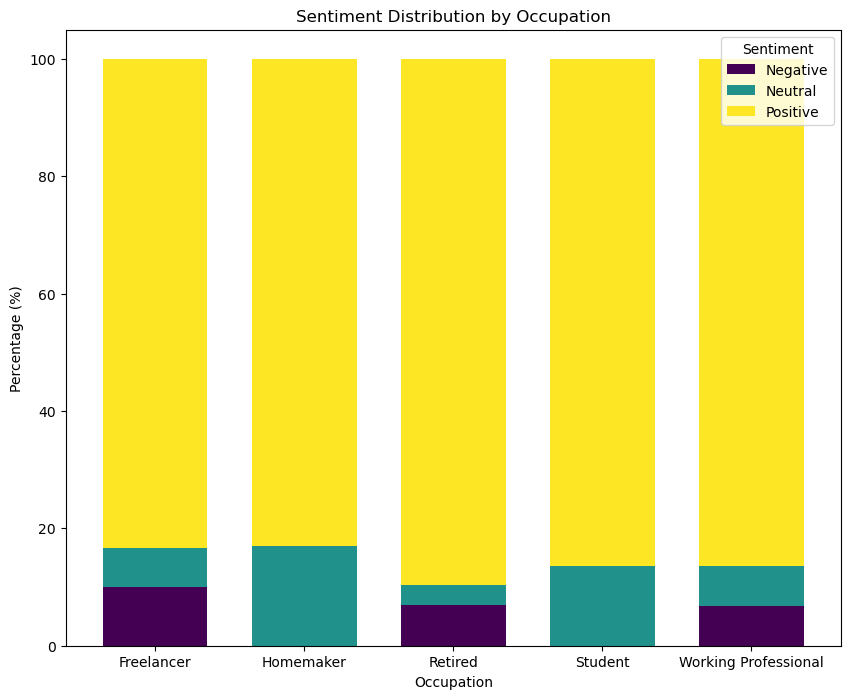

In [177]:
occupation_sentiment = df5.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_occupation(Redmi)[Sales Analysis].png")
plt.show()


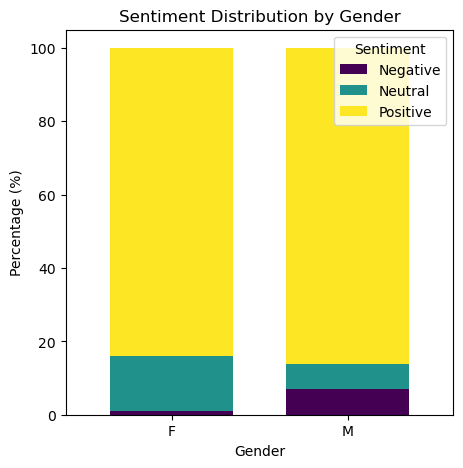

In [173]:
gender_sentiment = df5.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_by_gender(Redmi)[Sales Analysis].png")
plt.show()


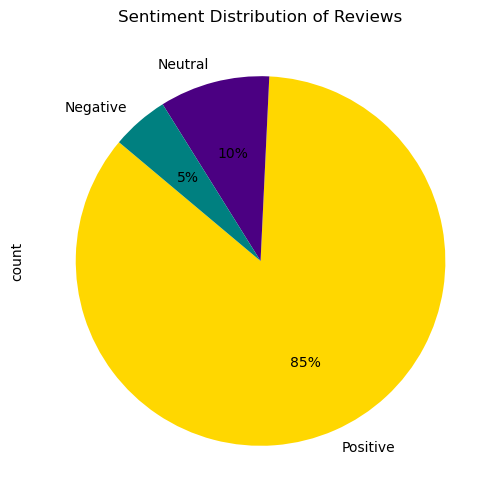

In [175]:
sentiment_counts = df5["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Redmi)[Sales Analysis].png")
plt.show()

In [179]:
df7 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df7.csv")
pd.DataFrame(df7)

,Reviews for Google Pixel Watch,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I have been using Pixel Watch 2 from the last ...,25-34,M,"Ghaziabad, Uttar Pradesh",Freelancer,September,2024,Q3
1,Yet another overpriced amazing looking unique ...,45-54,F,"Bengaluru, Karnataka",Working Professional,December,2024,Q4
2,The watch looks very stylish and the features ...,Under 18,F,"Miryalaguda, Telangana",Student,March,2020,Q1
3,Cool 😎 watch,45-54,M,"Canacona, Goa",Freelancer,October,2022,Q4
4,The amoled display and overall built are absol...,Under 18,M,"Irinjalakuda, Kerala",Student,January,2021,Q1
...,...,...,...,...,...,...,...,...
65,Perfect,25-34,F,"Patna, Bihar",Homemaker,December,2023,Q4
66,Top Notch!!!!!! ❤️,35-44,F,"Lucknow, Uttar Pradesh",Working Professional,January,2023,Q1
67,"Costly, but totally worth it. The AMOLED displ...",45-54,F,"Mumbai, Maharashtra",Homemaker,June,2021,Q2
68,This is the best watch from Google and is mile...,Under 18,M,"Kolkata, West Bengal",Student,June,2023,Q2


In [181]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df7.columns = df7.columns.str.strip()
review_column = "Reviews for Google Pixel Watch"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df7[['Polarity', 'Sentiment']] = df7[review_column].apply(analyze_sentiment)
print(df7.head())


                      Reviews for Google Pixel Watch       Age Gender  \
0  I have been using Pixel Watch 2 from the last ...     25-34      M   
1  Yet another overpriced amazing looking unique ...     45-54      F   
2  The watch looks very stylish and the features ...  Under 18      F   
3                                       Cool 😎 watch     45-54      M   
4  The amoled display and overall built are absol...  Under 18      M   

                    Location            Occupation      Month  Year Quarter  \
0   Ghaziabad, Uttar Pradesh            Freelancer  September  2024      Q3   
1       Bengaluru, Karnataka  Working Professional   December  2024      Q4   
2     Miryalaguda, Telangana               Student      March  2020      Q1   
3              Canacona, Goa            Freelancer    October  2022      Q4   
4       Irinjalakuda, Kerala               Student    January  2021      Q1   

   Polarity Sentiment  
0  0.370370  Positive  
1  0.558333  Positive  
2  0.825000  P

In [183]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df7['state'] = df7['Location'].astype(str).apply(extract_state)
df7

,Reviews for Google Pixel Watch,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I have been using Pixel Watch 2 from the last ...,25-34,M,"Ghaziabad, Uttar Pradesh",Freelancer,September,2024,Q3,0.370370,Positive,Uttar Pradesh
1,Yet another overpriced amazing looking unique ...,45-54,F,"Bengaluru, Karnataka",Working Professional,December,2024,Q4,0.558333,Positive,Karnataka
2,The watch looks very stylish and the features ...,Under 18,F,"Miryalaguda, Telangana",Student,March,2020,Q1,0.825000,Positive,Telangana
3,Cool 😎 watch,45-54,M,"Canacona, Goa",Freelancer,October,2022,Q4,0.350000,Positive,Goa
4,The amoled display and overall built are absol...,Under 18,M,"Irinjalakuda, Kerala",Student,January,2021,Q1,0.456061,Positive,Kerala
...,...,...,...,...,...,...,...,...,...,...,...
65,Perfect,25-34,F,"Patna, Bihar",Homemaker,December,2023,Q4,1.000000,Positive,Bihar
66,Top Notch!!!!!! ❤️,35-44,F,"Lucknow, Uttar Pradesh",Working Professional,January,2023,Q1,1.000000,Positive,Uttar Pradesh
67,"Costly, but totally worth it. The AMOLED displ...",45-54,F,"Mumbai, Maharashtra",Homemaker,June,2021,Q2,0.300000,Positive,Maharashtra
68,This is the best watch from Google and is mile...,Under 18,M,"Kolkata, West Bengal",Student,June,2023,Q2,0.750000,Positive,West Bengal


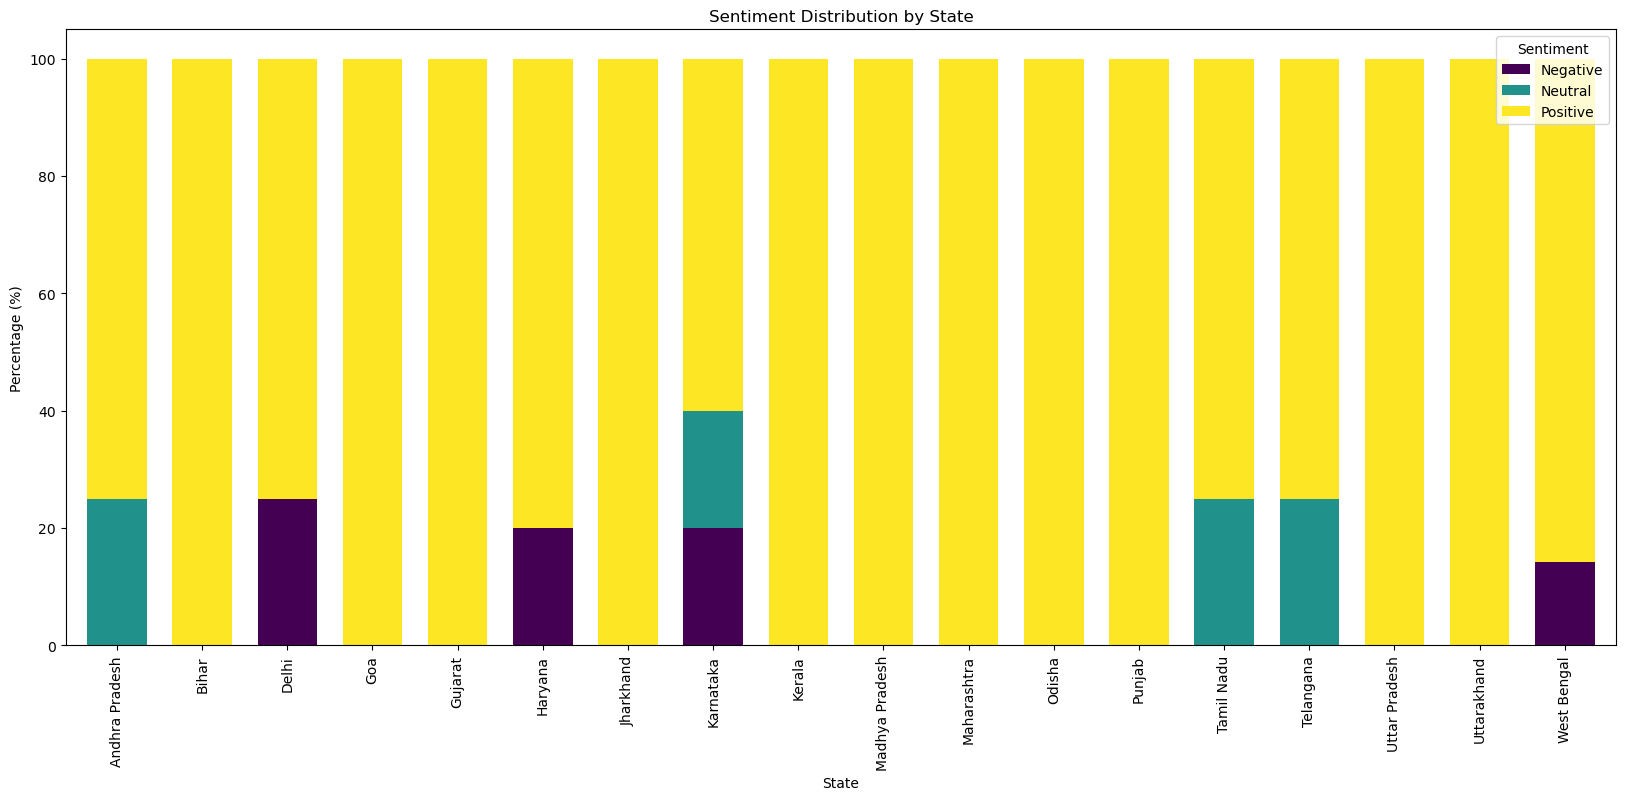

In [185]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df7.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Google)[Sales Analysis].png")
plt.show()

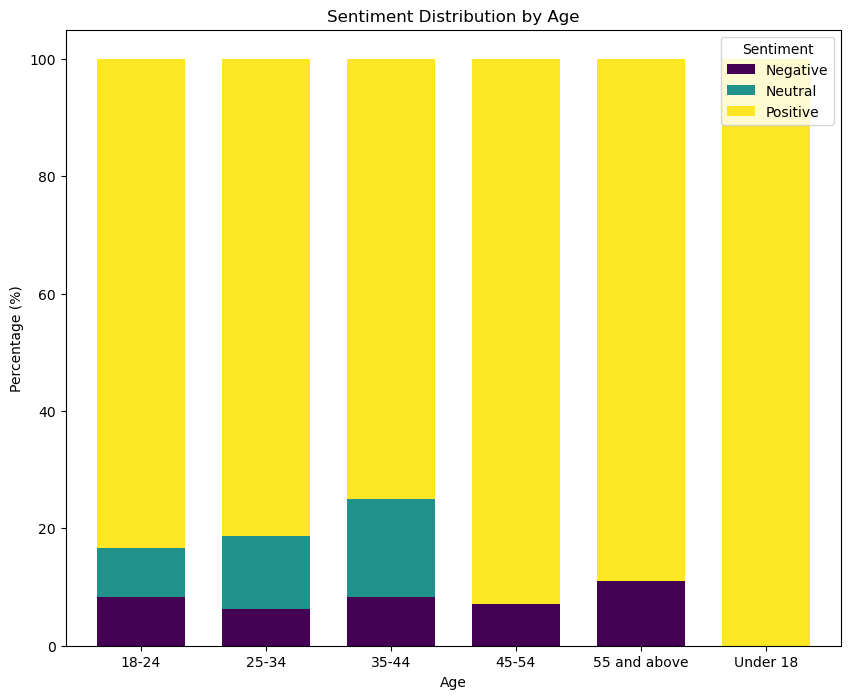

In [189]:
age_group_sentiment = df7.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Google)[Sales Analysis].png")
plt.show()


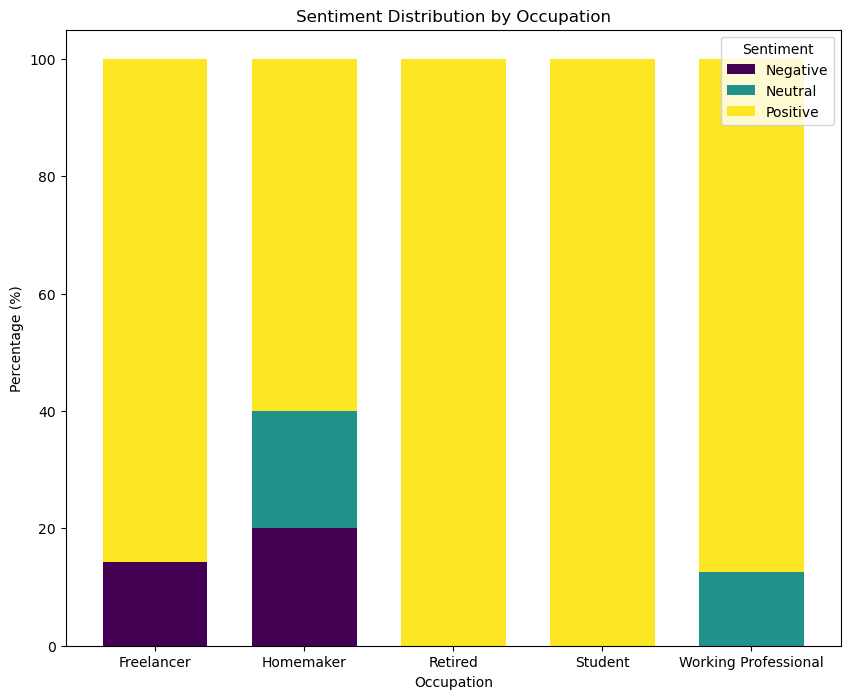

In [191]:
occupation_sentiment = df7.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Google)[Sales Analysis].png")
plt.show()


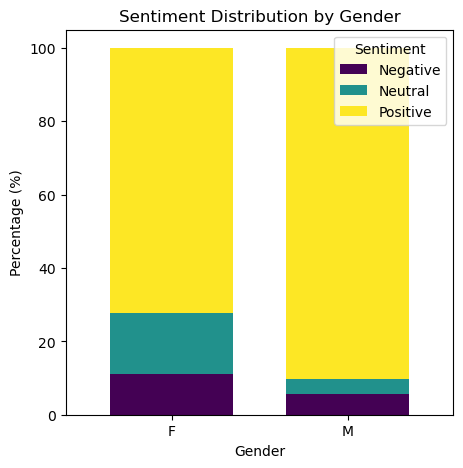

In [193]:
gender_sentiment = df7.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Google)[Sales Analysis].png")
plt.show()


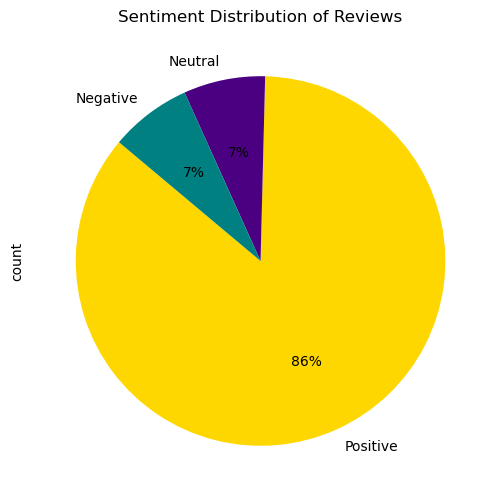

In [195]:
sentiment_counts = df7["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Google)[Sentiment Analysis].png")
plt.show()

In [197]:
df8 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df8.csv")
pd.DataFrame(df8)

,Reviews for Boat,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Boat smart watch is an impressive wearable dev...,Under 18,F,"Gauri Bazar, Uttar Pradesh",Student,July,2020,Q3
1,Product is very good 😊 love it,35-44,F,"Varanasi, Uttar Pradesh",Homemaker,March,2024,Q1
2,My friend tell about this it was so good produ...,18-24,F,"Madanapalle, Andhra Pradesh",Working Professional,November,2022,Q4
3,U have to charge Daily Or Every 2 Days . . . B...,35-44,M,"Surat, Gujarat",Working Professional,March,2024,Q1
4,Thnkss flipkart..,45-54,F,"Firozabad, Uttar Pradesh",Homemaker,February,2024,Q1
...,...,...,...,...,...,...,...,...
576,Noice,35-44,F,"Teleni Para, West Bengal",Homemaker,October,2020,Q4
577,"Cheating, there is no 100+cloud watch faces on...",55 and above,M,"Latur, Maharashtra",Retired,March,2023,Q1
578,Very nice,18-24,M,"Mumbai, Maharashtra",Freelancer,December,2021,Q4
579,Battery full charge working only 8 hours,Under 18,M,"Ambala, Haryana",Student,September,2023,Q3


In [199]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df8.columns = df8.columns.str.strip()
review_column = "Reviews for Boat"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df8[['Polarity', 'Sentiment']] = df8[review_column].apply(analyze_sentiment)
print(df8.head())


                                    Reviews for Boat       Age Gender  \
0  Boat smart watch is an impressive wearable dev...  Under 18      F   
1                     Product is very good 😊 love it     35-44      F   
2  My friend tell about this it was so good produ...     18-24      F   
3  U have to charge Daily Or Every 2 Days . . . B...     35-44      M   
4                                  Thnkss flipkart..     45-54      F   

                       Location            Occupation     Month  Year Quarter  \
0    Gauri Bazar, Uttar Pradesh               Student      July  2020      Q3   
1       Varanasi, Uttar Pradesh             Homemaker     March  2024      Q1   
2   Madanapalle, Andhra Pradesh  Working Professional  November  2022      Q4   
3                Surat, Gujarat  Working Professional     March  2024      Q1   
4      Firozabad, Uttar Pradesh             Homemaker  February  2024      Q1   

   Polarity Sentiment  
0  0.280612  Positive  
1  0.705000  Positive  
2 

In [201]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df8['state'] = df8['Location'].astype(str).apply(extract_state)
df8

,Reviews for Boat,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Boat smart watch is an impressive wearable dev...,Under 18,F,"Gauri Bazar, Uttar Pradesh",Student,July,2020,Q3,0.280612,Positive,Uttar Pradesh
1,Product is very good 😊 love it,35-44,F,"Varanasi, Uttar Pradesh",Homemaker,March,2024,Q1,0.705000,Positive,Uttar Pradesh
2,My friend tell about this it was so good produ...,18-24,F,"Madanapalle, Andhra Pradesh",Working Professional,November,2022,Q4,0.700000,Positive,Andhra Pradesh
3,U have to charge Daily Or Every 2 Days . . . B...,35-44,M,"Surat, Gujarat",Working Professional,March,2024,Q1,0.031250,Positive,Gujarat
4,Thnkss flipkart..,45-54,F,"Firozabad, Uttar Pradesh",Homemaker,February,2024,Q1,0.000000,Neutral,Uttar Pradesh
...,...,...,...,...,...,...,...,...,...,...,...
576,Noice,35-44,F,"Teleni Para, West Bengal",Homemaker,October,2020,Q4,0.000000,Neutral,West Bengal
577,"Cheating, there is no 100+cloud watch faces on...",55 and above,M,"Latur, Maharashtra",Retired,March,2023,Q1,-0.108333,Negative,Maharashtra
578,Very nice,18-24,M,"Mumbai, Maharashtra",Freelancer,December,2021,Q4,0.780000,Positive,Maharashtra
579,Battery full charge working only 8 hours,Under 18,M,"Ambala, Haryana",Student,September,2023,Q3,0.175000,Positive,Haryana


In [205]:
df8 = df8[df8['state'] != 'Maharshtra']
df8 = df8[df8['state'] != 'West bengal']

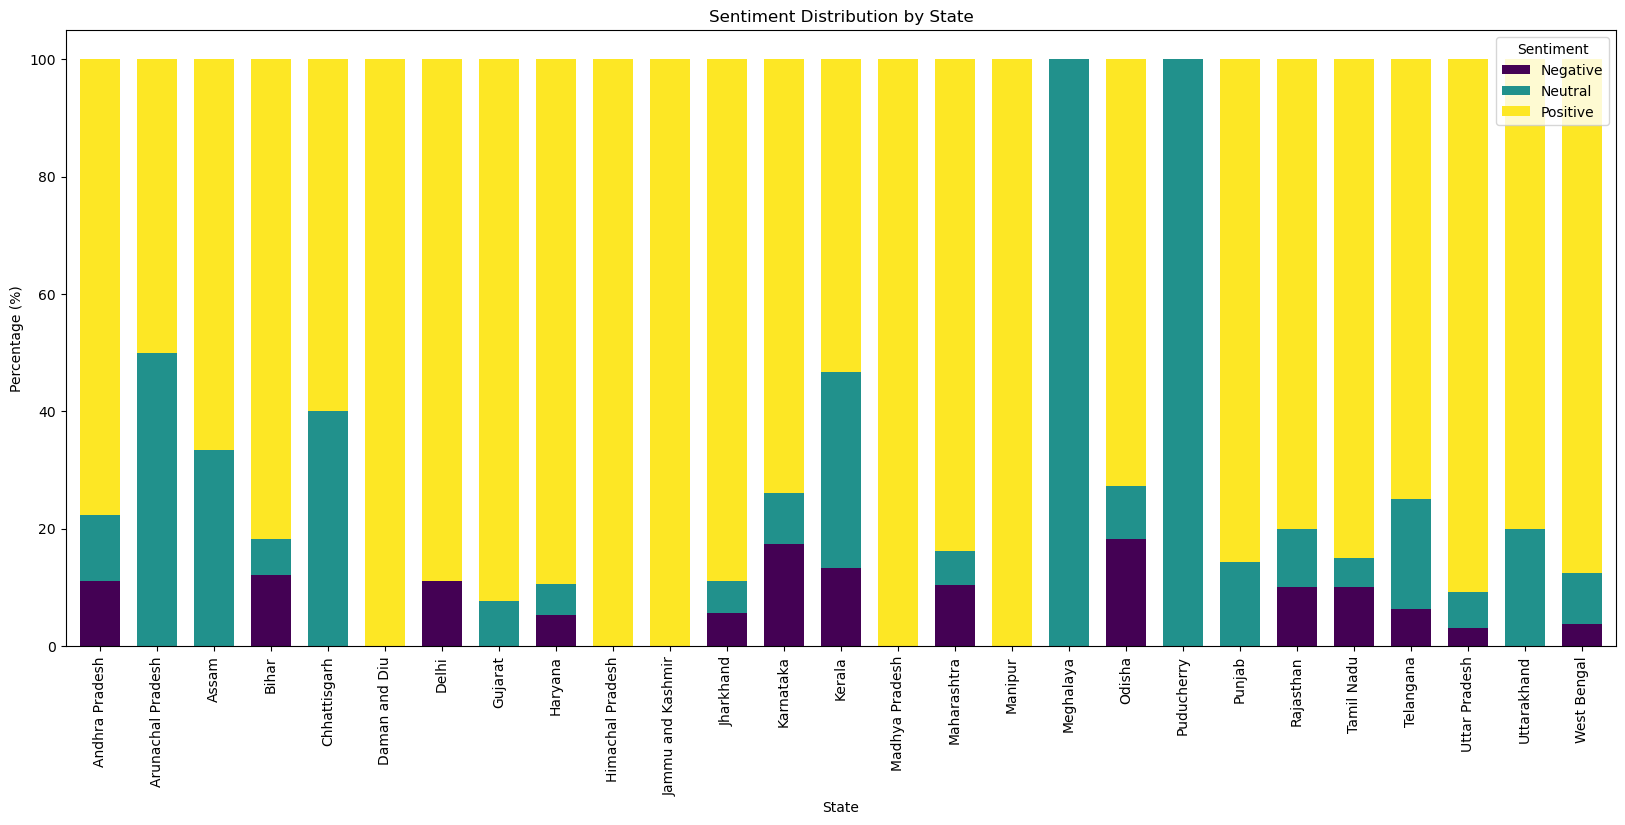

In [207]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df8.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Boat)[Sales Analysis].png")
plt.show()

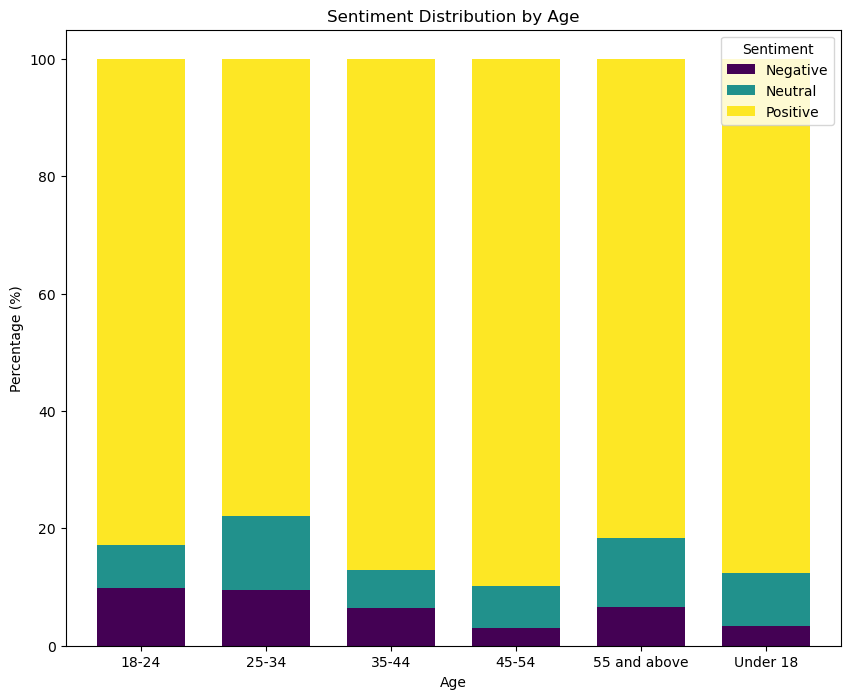

In [209]:
age_group_sentiment = df8.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Boat)[Sales Analysis].png")
plt.show()


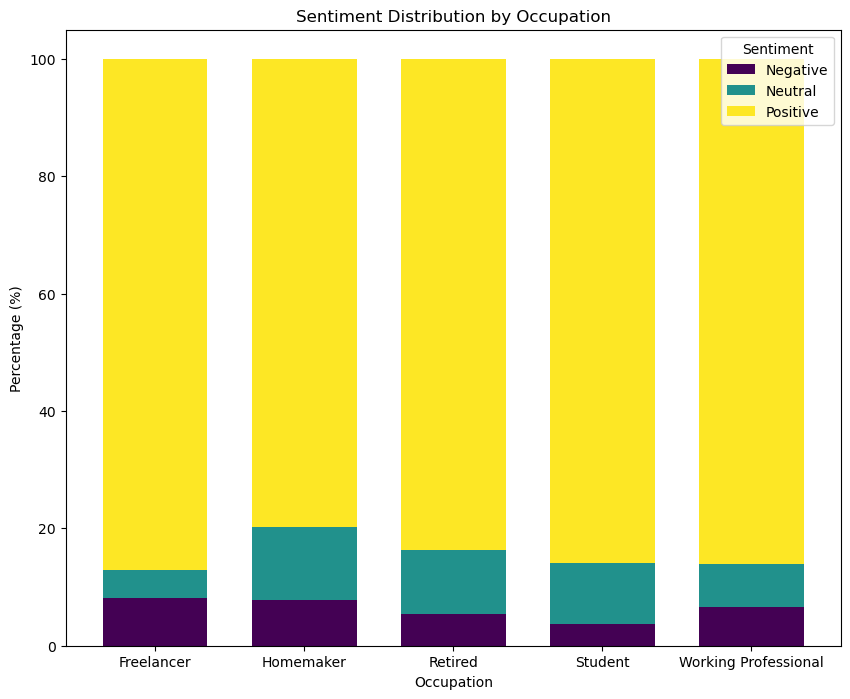

In [211]:
occupation_sentiment = df8.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Boat)[Sales Analysis].png")
plt.show()


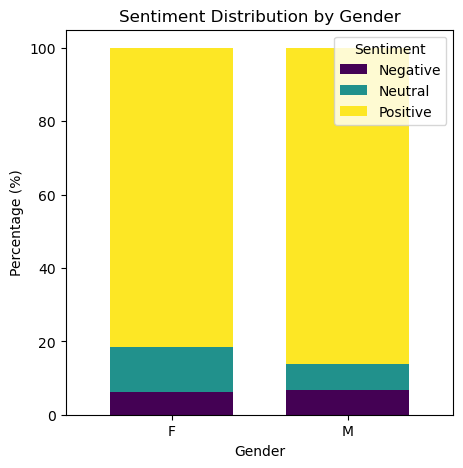

In [213]:
gender_sentiment = df8.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Boat)[Sales Analysis].png")
plt.show()


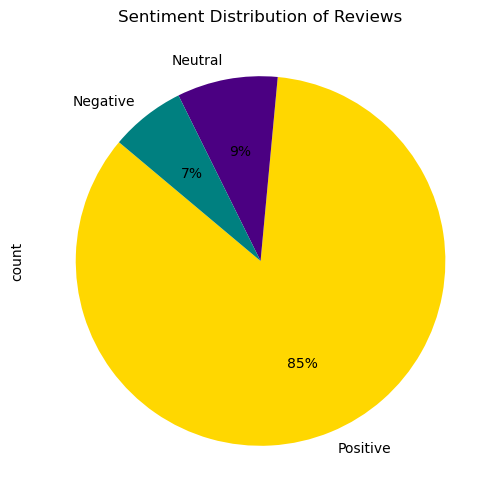

In [215]:
sentiment_counts = df8["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Boat)[Sentiment Analysis].png")
plt.show()

In [217]:
df10 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df10.csv")
pd.DataFrame(df10)

,Reviews for Fireboltt,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I am using it from a day. It's really good loo...,25-34,M,"Tumkur, Karnataka",Working Professional,November,2024,Q4
1,Nice watch' good deal thnx Flipkart\nI need on...,55 and above,M,"Mumbai, Maharashtra",Retired,May,2023,Q2
2,"Very nice, I have bought for child, he so mush...",25-34,F,"Kanpur, Uttar Pradesh",Homemaker,December,2024,Q4
3,Superb i m impressed,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2
4,Loved it,35-44,M,"New Town, West Bengal",Freelancer,January,2020,Q1
...,...,...,...,...,...,...,...,...
908,We can't call anyone through Bluetooth.But we ...,45-54,F,"Kanjiramkulam, Kerala",Homemaker,August,2020,Q3
909,Good watch,Under 18,M,"Vadodara, Gujarat",Student,August,2022,Q3
910,Very nice ✅✅product,18-24,M,"Ranchi, Jharkhand",Freelancer,April,2023,Q2
911,This to good for the money I paid,Under 18,M,"Bengaluru, Karnataka",Student,June,2021,Q2


In [219]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df10.columns = df10.columns.str.strip()
review_column = "Reviews for Fireboltt"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df10[['Polarity', 'Sentiment']] = df10[review_column].apply(analyze_sentiment)
print(df10.head())


                               Reviews for Fireboltt           Age Gender  \
0  I am using it from a day. It's really good loo...         25-34      M   
1  Nice watch' good deal thnx Flipkart\nI need on...  55 and above      M   
2  Very nice, I have bought for child, he so mush...         25-34      F   
3                               Superb i m impressed         25-34      F   
4                                           Loved it         35-44      M   

                 Location            Occupation     Month  Year Quarter  \
0       Tumkur, Karnataka  Working Professional  November  2024      Q4   
1     Mumbai, Maharashtra               Retired       May  2023      Q2   
2   Kanpur, Uttar Pradesh             Homemaker  December  2024      Q4   
3     Chennai, Tamil Nadu             Homemaker     April  2021      Q2   
4   New Town, West Bengal            Freelancer   January  2020      Q1   

   Polarity Sentiment  
0  0.788333  Positive  
1  0.682000  Positive  
2  0.780000  P

In [221]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df10['state'] = df10['Location'].astype(str).apply(extract_state)
df10

,Reviews for Fireboltt,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I am using it from a day. It's really good loo...,25-34,M,"Tumkur, Karnataka",Working Professional,November,2024,Q4,0.788333,Positive,Karnataka
1,Nice watch' good deal thnx Flipkart\nI need on...,55 and above,M,"Mumbai, Maharashtra",Retired,May,2023,Q2,0.682000,Positive,Maharashtra
2,"Very nice, I have bought for child, he so mush...",25-34,F,"Kanpur, Uttar Pradesh",Homemaker,December,2024,Q4,0.780000,Positive,Uttar Pradesh
3,Superb i m impressed,25-34,F,"Chennai, Tamil Nadu",Homemaker,April,2021,Q2,1.000000,Positive,Tamil Nadu
4,Loved it,35-44,M,"New Town, West Bengal",Freelancer,January,2020,Q1,0.700000,Positive,West Bengal
...,...,...,...,...,...,...,...,...,...,...,...
908,We can't call anyone through Bluetooth.But we ...,45-54,F,"Kanjiramkulam, Kerala",Homemaker,August,2020,Q3,0.150000,Positive,Kerala
909,Good watch,Under 18,M,"Vadodara, Gujarat",Student,August,2022,Q3,0.700000,Positive,Gujarat
910,Very nice ✅✅product,18-24,M,"Ranchi, Jharkhand",Freelancer,April,2023,Q2,0.780000,Positive,Jharkhand
911,This to good for the money I paid,Under 18,M,"Bengaluru, Karnataka",Student,June,2021,Q2,0.700000,Positive,Karnataka


In [229]:
df10 = df10[df10['state'] != 'Maharashtraa']
df10 = df10[df10['state'] != 'Maharshtra']
df10 = df10[df10['state'] != 'Odiisha']

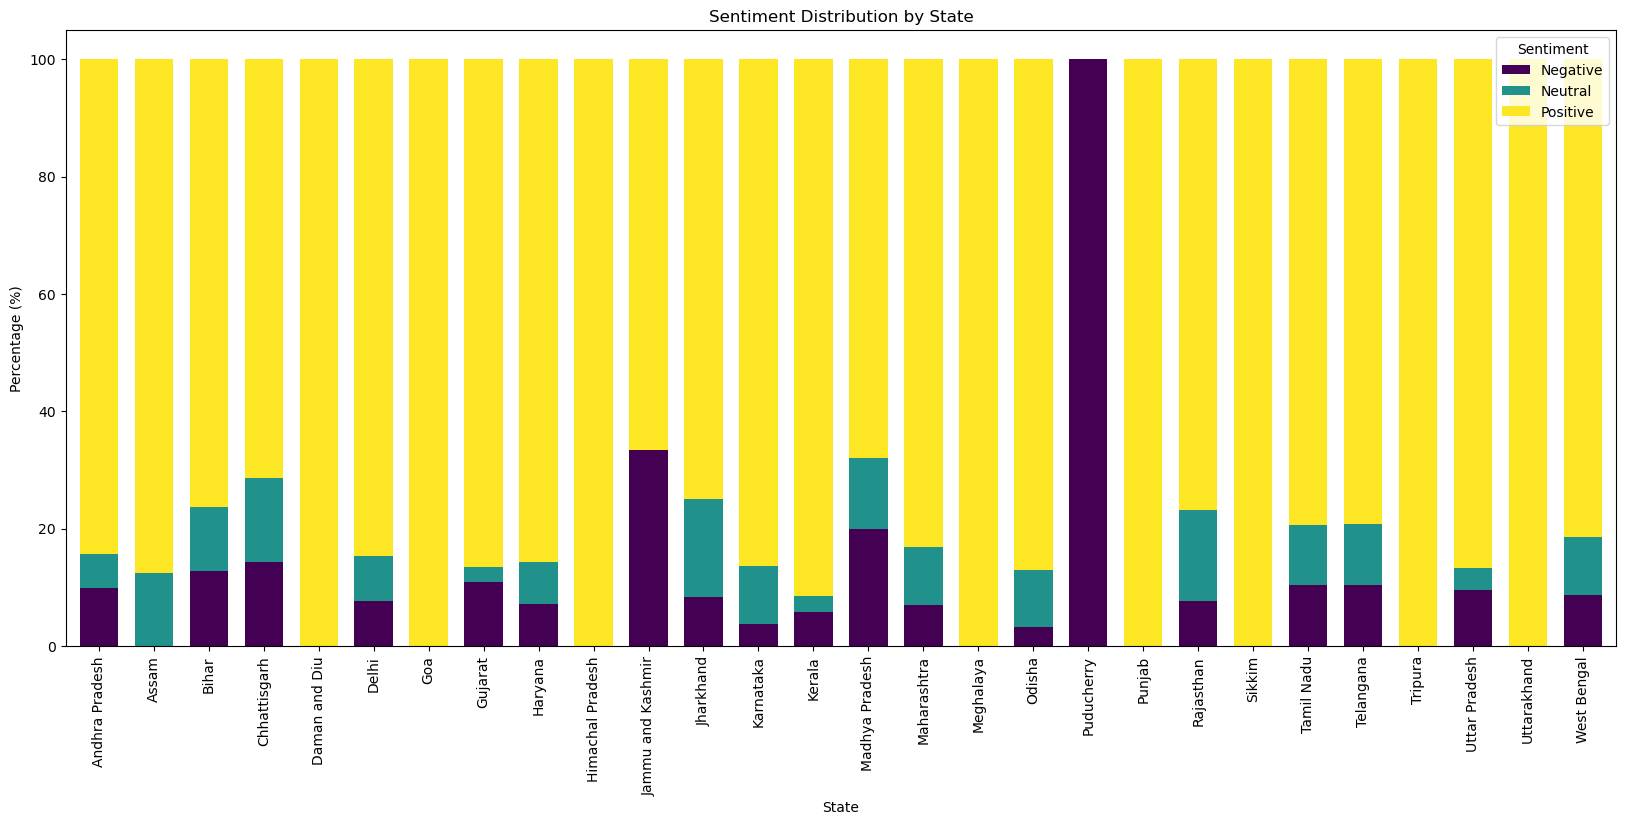

In [231]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df10.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Fireboltt)[Sales Analysis].png")
plt.show()

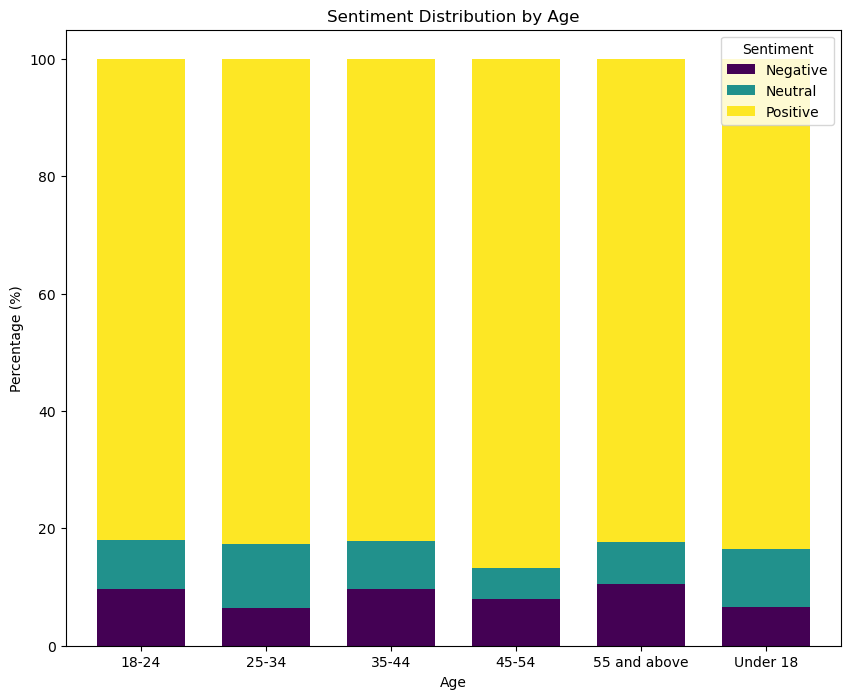

In [233]:
age_group_sentiment = df10.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Fireboltt)[Sales Analysis].png")
plt.show()


In [237]:
df10 = df10[df10['Occupation'] != 'R']

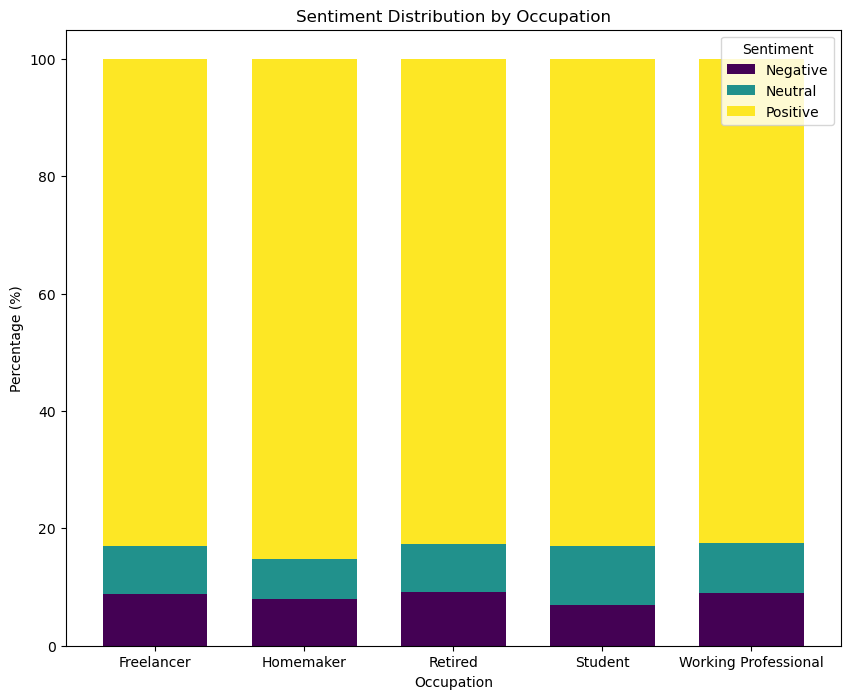

In [239]:
occupation_sentiment = df10.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Fireboltt)[Sales Analysis].png")
plt.show()


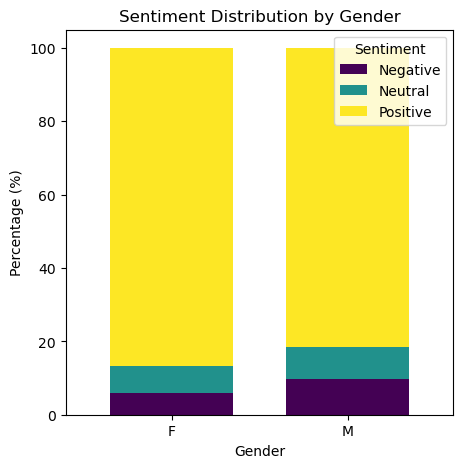

In [241]:
gender_sentiment = df10.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Fireboltt)[Sales Analysis].png")
plt.show()


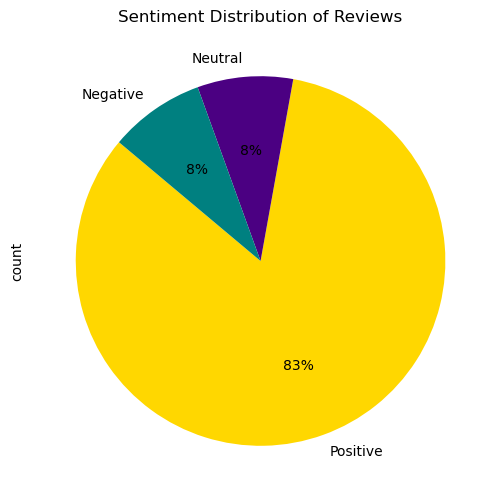

In [243]:
sentiment_counts = df10["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Fireboltt)[Sentiment Analysis].png")
plt.show()

In [245]:
df11 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df11.csv")
pd.DataFrame(df11)

,Reviews for FitBit,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I wasn't a great fan of activity monitors but ...,25-34,F,"Hyderabad, Telangana",Homemaker,May,2022,Q2
1,My wife wanted a smart watch which could guess...,55 and above,M,"Udupi, Karnataka",Retired,July,2023,Q3
2,"Overall the look and the features are good, ho...",35-44,F,"Kolkata, West Bengal",Homemaker,February,2021,Q1
3,Every day I am falling in love with this versa...,25-34,F,"Kanakapura, Karnataka",Homemaker,July,2024,Q3
4,wonderful product,55 and above,M,"Mahindra World City, Tamil Nadu",Student,November,2021,Q4
...,...,...,...,...,...,...,...,...
296,Very good smart watch..,35-44,M,"Dharapuram, Tamil Nadu",Working Professional,November,2022,Q4
297,Great,55 and above,F,"Ludhiana, Punjab",Homemaker,March,2021,Q1
298,Excellent watch..\nWorth to buy,Under 18,F,"Raman, Punjab",Student,July,2022,Q3
299,please don't go for versa 3. The watch softwar...,18-24,F,"Thiruvananthapuram, Kerala",Working Professional,April,2021,Q2


In [249]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df11.columns = df11.columns.str.strip()
review_column = "Reviews for FitBit"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df11[['Polarity', 'Sentiment']] = df11[review_column].apply(analyze_sentiment)
print(df11.head())


                                  Reviews for FitBit           Age Gender  \
0  I wasn't a great fan of activity monitors but ...         25-34      F   
1  My wife wanted a smart watch which could guess...  55 and above      M   
2  Overall the look and the features are good, ho...         35-44      F   
3  Every day I am falling in love with this versa...         25-34      F   
4                                  wonderful product  55 and above      M   

                           Location Occupation     Month  Year Quarter  \
0              Hyderabad, Telangana  Homemaker       May  2022      Q2   
1                  Udupi, Karnataka    Retired      July  2023      Q3   
2              Kolkata, West Bengal  Homemaker  February  2021      Q1   
3             Kanakapura, Karnataka  Homemaker      July  2024      Q3   
4   Mahindra World City, Tamil Nadu    Student  November  2021      Q4   

   Polarity Sentiment  
0  0.290741  Positive  
1  0.082857  Positive  
2  0.190152  Positiv

In [251]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df11['state'] = df11['Location'].astype(str).apply(extract_state)
df11

,Reviews for FitBit,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I wasn't a great fan of activity monitors but ...,25-34,F,"Hyderabad, Telangana",Homemaker,May,2022,Q2,0.290741,Positive,Telangana
1,My wife wanted a smart watch which could guess...,55 and above,M,"Udupi, Karnataka",Retired,July,2023,Q3,0.082857,Positive,Karnataka
2,"Overall the look and the features are good, ho...",35-44,F,"Kolkata, West Bengal",Homemaker,February,2021,Q1,0.190152,Positive,West Bengal
3,Every day I am falling in love with this versa...,25-34,F,"Kanakapura, Karnataka",Homemaker,July,2024,Q3,0.333333,Positive,Karnataka
4,wonderful product,55 and above,M,"Mahindra World City, Tamil Nadu",Student,November,2021,Q4,1.000000,Positive,Tamil Nadu
...,...,...,...,...,...,...,...,...,...,...,...
296,Very good smart watch..,35-44,M,"Dharapuram, Tamil Nadu",Working Professional,November,2022,Q4,0.562143,Positive,Tamil Nadu
297,Great,55 and above,F,"Ludhiana, Punjab",Homemaker,March,2021,Q1,0.800000,Positive,Punjab
298,Excellent watch..\nWorth to buy,Under 18,F,"Raman, Punjab",Student,July,2022,Q3,0.650000,Positive,Punjab
299,please don't go for versa 3. The watch softwar...,18-24,F,"Thiruvananthapuram, Kerala",Working Professional,April,2021,Q2,-0.225397,Negative,Kerala


In [259]:
df11 = df11[df11['state'] != 'Maharshtra']

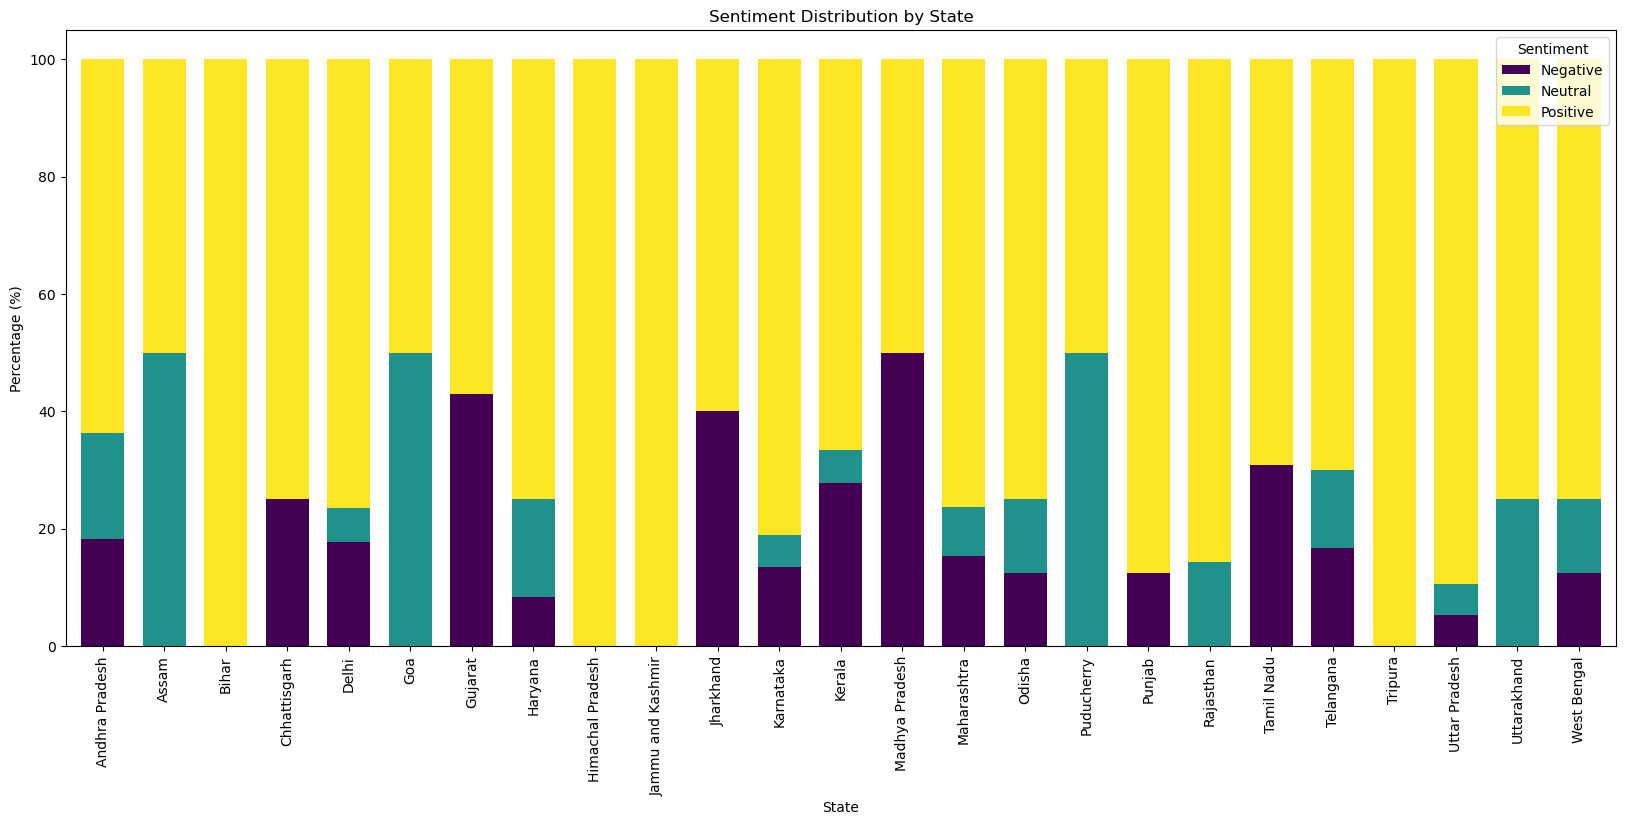

In [261]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df11.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(FitBit)[Sales Analysis].png")
plt.show()

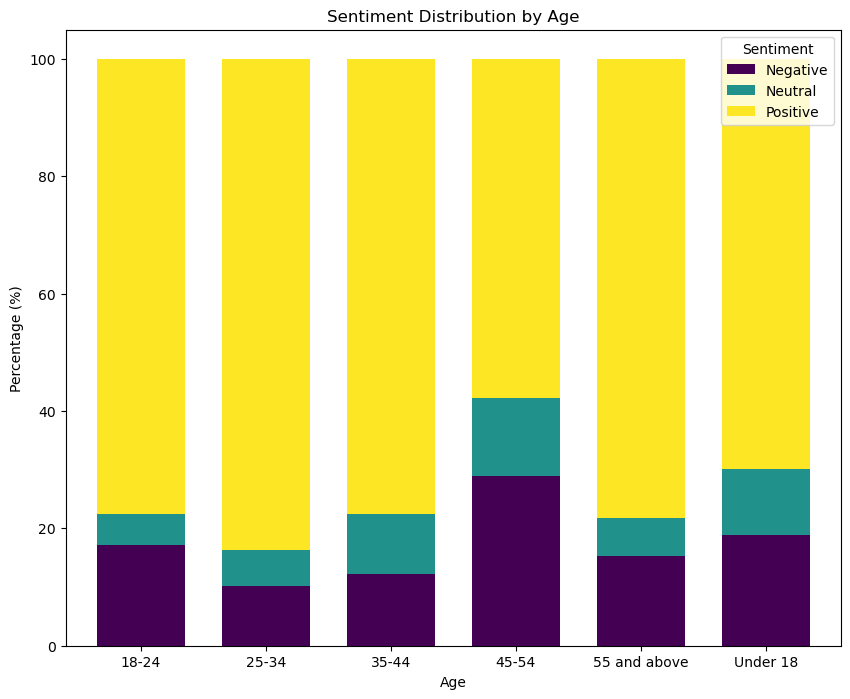

In [263]:
age_group_sentiment = df11.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(FitBit)[Sales Analysis].png")
plt.show()


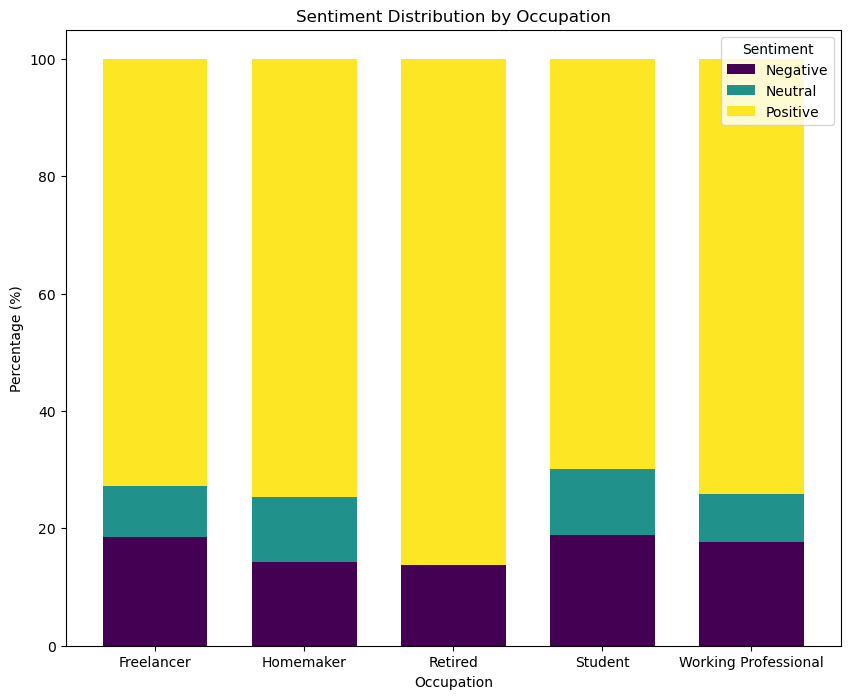

In [265]:
occupation_sentiment = df11.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(FitBit)[Sales Analysis].png")
plt.show()


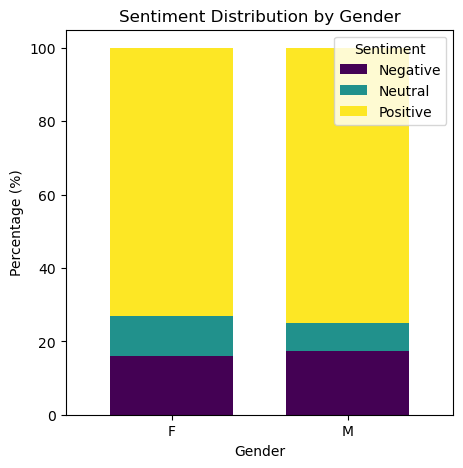

In [267]:
gender_sentiment = df11.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(FitBit)[Sales Analysis].png")
plt.show()


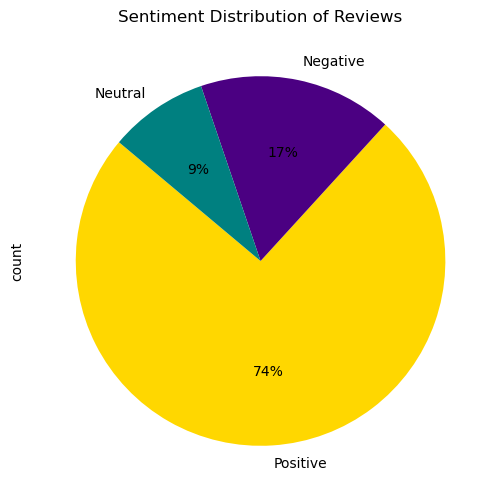

In [269]:
sentiment_counts = df11["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(FitBit)[Sentiment Analysis].png")
plt.show()

In [271]:
df12 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df12.csv")
pd.DataFrame(df12)

,Reviews for Boult,Age,Gender,Location,Occupation,Month,Year,Quarter
0,Awesome watch with overloaded features. And it...,25-34,M,"Muzaffarnagar, Uttar Pradesh",Freelancer,January,2022,Q1
1,Good product and best Quality,25-34,M,"Raigarh, Chhattisgarh",Working Professional,August,2021,Q3
2,"Value For Money Product, But Battary Drain Ver...",25-34,M,"Kolhapur, Maharashtra",Working Professional,February,2021,Q1
3,Nice watch very happy 😊,55 and above,F,"Saharsa, Bihar",Homemaker,December,2022,Q4
4,Look wise very good features is decent as othe...,Under 18,F,"Buldhana, Maharashtra",Student,September,2024,Q3
...,...,...,...,...,...,...,...,...
693,Nice 👍,45-54,M,"Janjgir, Chhattisgarh",Working Professional,August,2021,Q3
694,Good product...,35-44,M,"South Twenty Four Parganas District, West Bengal",Working Professional,December,2022,Q4
695,Product is very good 👍😊\nHappy 😊,45-54,M,"Mumbai, Maharashtra",Working Professional,February,2020,Q1
696,Very good,55 and above,F,"Vijalpor, Gujarat",Homemaker,October,2024,Q4


In [273]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df12.columns = df12.columns.str.strip()
review_column = "Reviews for Boult"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df12[['Polarity', 'Sentiment']] = df12[review_column].apply(analyze_sentiment)
print(df12.head())


                                   Reviews for Boult           Age Gender  \
0  Awesome watch with overloaded features. And it...         25-34      M   
1                      Good product and best Quality         25-34      M   
2  Value For Money Product, But Battary Drain Ver...         25-34      M   
3                            Nice watch very happy 😊  55 and above      F   
4  Look wise very good features is decent as othe...      Under 18      F   

                        Location            Occupation      Month  Year  \
0   Muzaffarnagar, Uttar Pradesh            Freelancer    January  2022   
1         Raigarh, Chhattisgarh   Working Professional     August  2021   
2          Kolhapur, Maharashtra  Working Professional   February  2021   
3                Saharsa, Bihar              Homemaker   December  2022   
4          Buldhana, Maharashtra               Student  September  2024   

  Quarter  Polarity Sentiment  
0      Q1  0.739333  Positive  
1      Q3  0.850000  P

In [275]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df12['state'] = df12['Location'].astype(str).apply(extract_state)
df12

,Reviews for Boult,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,Awesome watch with overloaded features. And it...,25-34,M,"Muzaffarnagar, Uttar Pradesh",Freelancer,January,2022,Q1,0.739333,Positive,Uttar Pradesh
1,Good product and best Quality,25-34,M,"Raigarh, Chhattisgarh",Working Professional,August,2021,Q3,0.850000,Positive,Chhattisgarh
2,"Value For Money Product, But Battary Drain Ver...",25-34,M,"Kolhapur, Maharashtra",Working Professional,February,2021,Q1,0.268571,Positive,Maharashtra
3,Nice watch very happy 😊,55 and above,F,"Saharsa, Bihar",Homemaker,December,2022,Q4,0.800000,Positive,Bihar
4,Look wise very good features is decent as othe...,Under 18,F,"Buldhana, Maharashtra",Student,September,2024,Q3,0.412917,Positive,Maharashtra
...,...,...,...,...,...,...,...,...,...,...,...
693,Nice 👍,45-54,M,"Janjgir, Chhattisgarh",Working Professional,August,2021,Q3,0.600000,Positive,Chhattisgarh
694,Good product...,35-44,M,"South Twenty Four Parganas District, West Bengal",Working Professional,December,2022,Q4,0.700000,Positive,West Bengal
695,Product is very good 👍😊\nHappy 😊,45-54,M,"Mumbai, Maharashtra",Working Professional,February,2020,Q1,0.855000,Positive,Maharashtra
696,Very good,55 and above,F,"Vijalpor, Gujarat",Homemaker,October,2024,Q4,0.910000,Positive,Gujarat


In [279]:
df12 = df12[df12['state'] != 'Maharshtra']
df12 = df12[df12['state'] != 'West bengal']

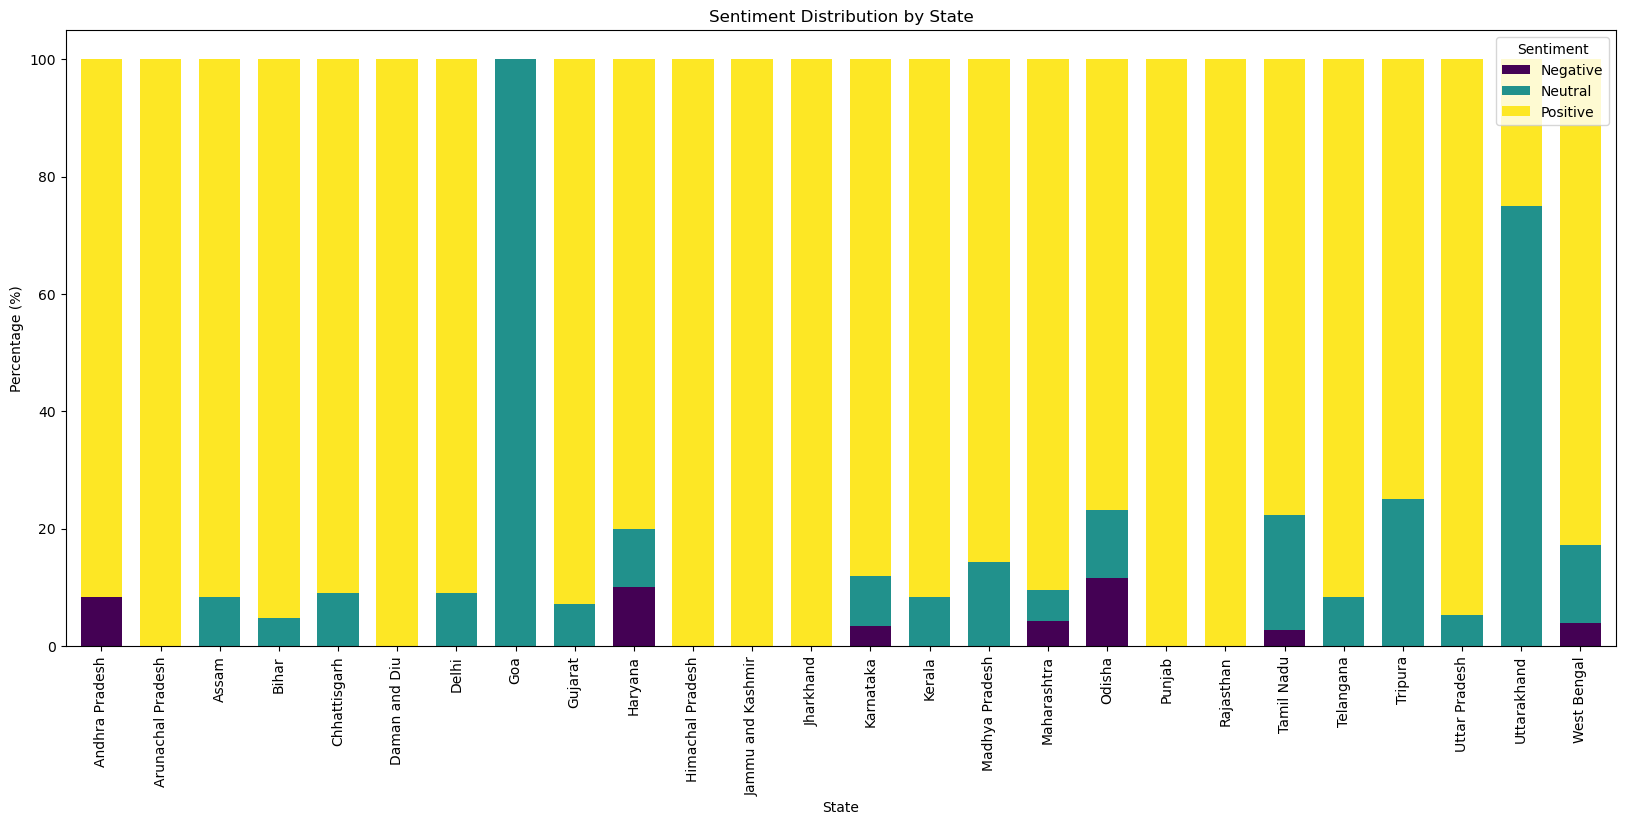

In [281]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df12.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Boult)[Sales Analysis].png")
plt.show()

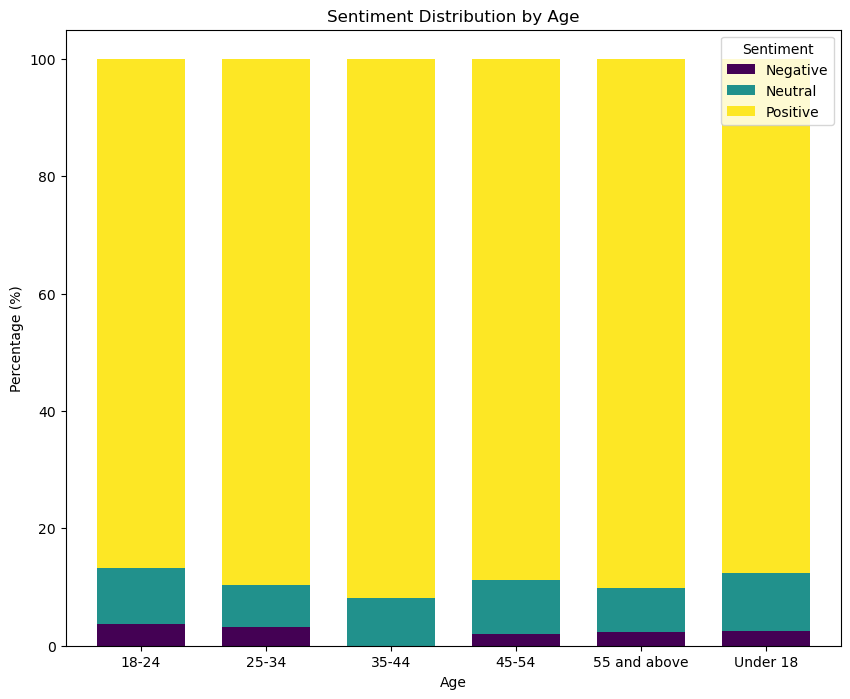

In [283]:
age_group_sentiment = df12.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Boult)[Sales Analysis].png")
plt.show()


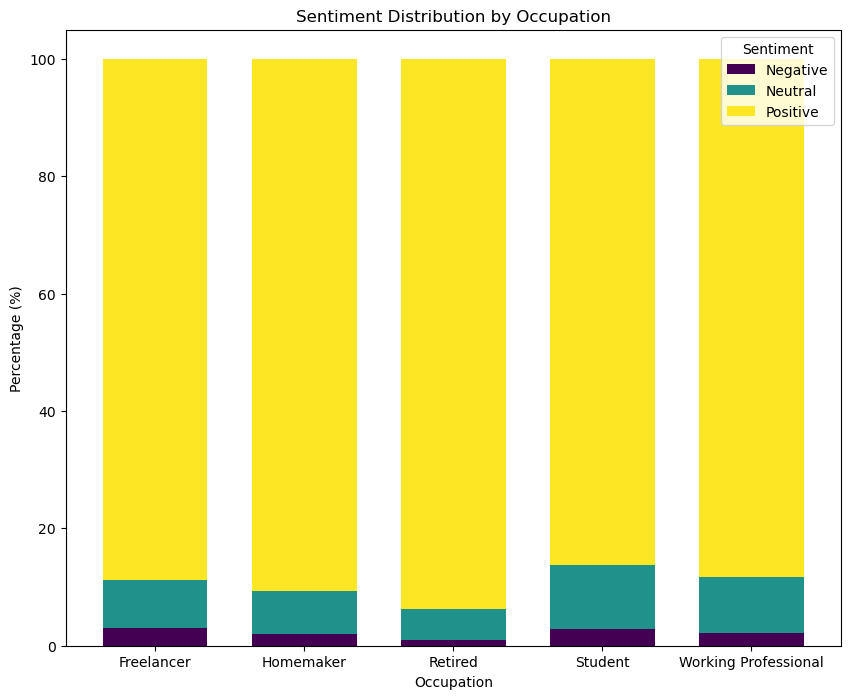

In [285]:
occupation_sentiment = df12.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Boult)[Sales Analysis].png")
plt.show()


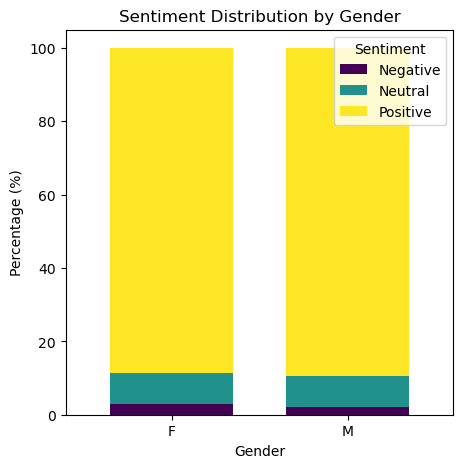

In [287]:
gender_sentiment = df12.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Boult)[Sales Analysis].png")
plt.show()


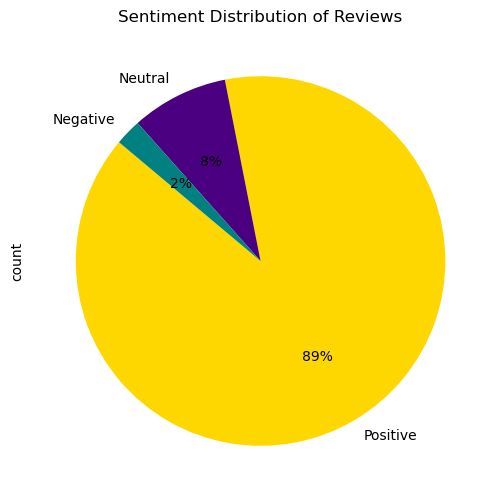

In [289]:
sentiment_counts = df12["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Boult)[Sentiment Analysis].png")
plt.show()

In [291]:
df13 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df13.csv")
pd.DataFrame(df13)

,Reviews for Amazfit,Age,Gender,Location,Occupation,Month,Year,Quarter
0,It's not a watch but a sophisticated / premium...,18-24,M,"Indore, Madhya Pradesh",Working Professional,May,2021,Q2
1,Just awesome\nDisplay is very nice\nNo lagging...,55 and above,M,"Panihati, West Bengal",Retired,August,2021,Q3
2,Superb watch this watch is amazing\nRealme and...,18-24,M,"East Delhi, Delhi",Working Professional,August,2021,Q3
3,Bestest smartwatch ⌚ ever 😍\nI really liked it...,25-34,M,"Bara Banki, Jharkhand",Freelancer,April,2020,Q2
4,I love this watch ❤️❤️I buy for my sister she ...,25-34,F,"Ullal, Karnataka",Homemaker,July,2022,Q3
...,...,...,...,...,...,...,...,...
589,One of the best smart watch. Top notch quality...,45-54,M,"Hoshiarpur, Punjab",Freelancer,August,2020,Q3
590,"When I bought it my first impression was good,...",55 and above,M,"Dimapur, Nagaland",Retired,February,2022,Q1
591,I liked the product. Straps should be of leath...,35-44,M,"Jammu, Jammu and Kashmir",Working Professional,November,2024,Q4
592,Style and Performance watch.,35-44,F,"Hyderabad, Telangana",Homemaker,September,2023,Q3


In [295]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df13.columns = df13.columns.str.strip()
review_column = "Reviews for Amazfit"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df13[['Polarity', 'Sentiment']] = df13[review_column].apply(analyze_sentiment)
print(df13.head())


                                 Reviews for Amazfit           Age Gender  \
0  It's not a watch but a sophisticated / premium...         18-24      M   
1  Just awesome\nDisplay is very nice\nNo lagging...  55 and above      M   
2  Superb watch this watch is amazing\nRealme and...         18-24      M   
3  Bestest smartwatch ⌚ ever 😍\nI really liked it...         25-34      M   
4  I love this watch ❤️❤️I buy for my sister she ...         25-34      F   

                  Location            Occupation   Month  Year Quarter  \
0   Indore, Madhya Pradesh  Working Professional     May  2021      Q2   
1    Panihati, West Bengal               Retired  August  2021      Q3   
2        East Delhi, Delhi  Working Professional  August  2021      Q3   
3    Bara Banki, Jharkhand            Freelancer   April  2020      Q2   
4         Ullal, Karnataka             Homemaker    July  2022      Q3   

   Polarity Sentiment  
0  0.250693  Positive  
1  0.726667  Positive  
2  0.366667  Positiv

In [297]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df13['state'] = df13['Location'].astype(str).apply(extract_state)
df13

,Reviews for Amazfit,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,It's not a watch but a sophisticated / premium...,18-24,M,"Indore, Madhya Pradesh",Working Professional,May,2021,Q2,0.250693,Positive,Madhya Pradesh
1,Just awesome\nDisplay is very nice\nNo lagging...,55 and above,M,"Panihati, West Bengal",Retired,August,2021,Q3,0.726667,Positive,West Bengal
2,Superb watch this watch is amazing\nRealme and...,18-24,M,"East Delhi, Delhi",Working Professional,August,2021,Q3,0.366667,Positive,Delhi
3,Bestest smartwatch ⌚ ever 😍\nI really liked it...,25-34,M,"Bara Banki, Jharkhand",Freelancer,April,2020,Q2,0.783333,Positive,Jharkhand
4,I love this watch ❤️❤️I buy for my sister she ...,25-34,F,"Ullal, Karnataka",Homemaker,July,2022,Q3,0.750000,Positive,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...
589,One of the best smart watch. Top notch quality...,45-54,M,"Hoshiarpur, Punjab",Freelancer,August,2020,Q3,0.571429,Positive,Punjab
590,"When I bought it my first impression was good,...",55 and above,M,"Dimapur, Nagaland",Retired,February,2022,Q1,0.485000,Positive,Nagaland
591,I liked the product. Straps should be of leath...,35-44,M,"Jammu, Jammu and Kashmir",Working Professional,November,2024,Q4,0.500000,Positive,Jammu and Kashmir
592,Style and Performance watch.,35-44,F,"Hyderabad, Telangana",Homemaker,September,2023,Q3,0.000000,Neutral,Telangana


In [301]:
df13 = df13[df13['state'] != 'Maharshtra']
df13 = df13[df13['state'] != 'Maharashtraa']

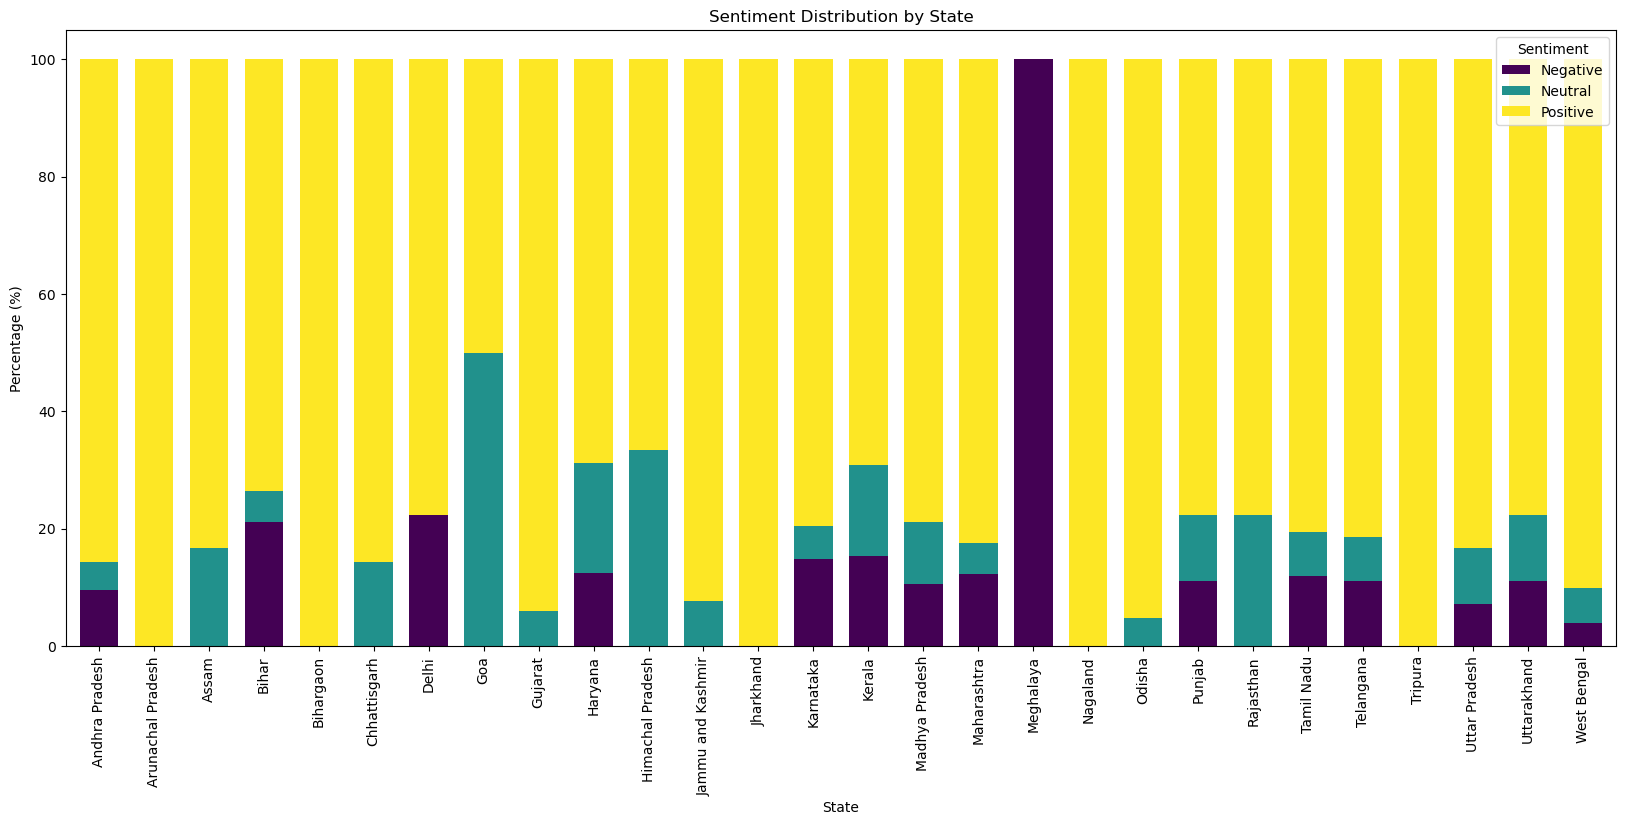

In [303]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df13.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Amazfit)[Sales Analysis].png")
plt.show()

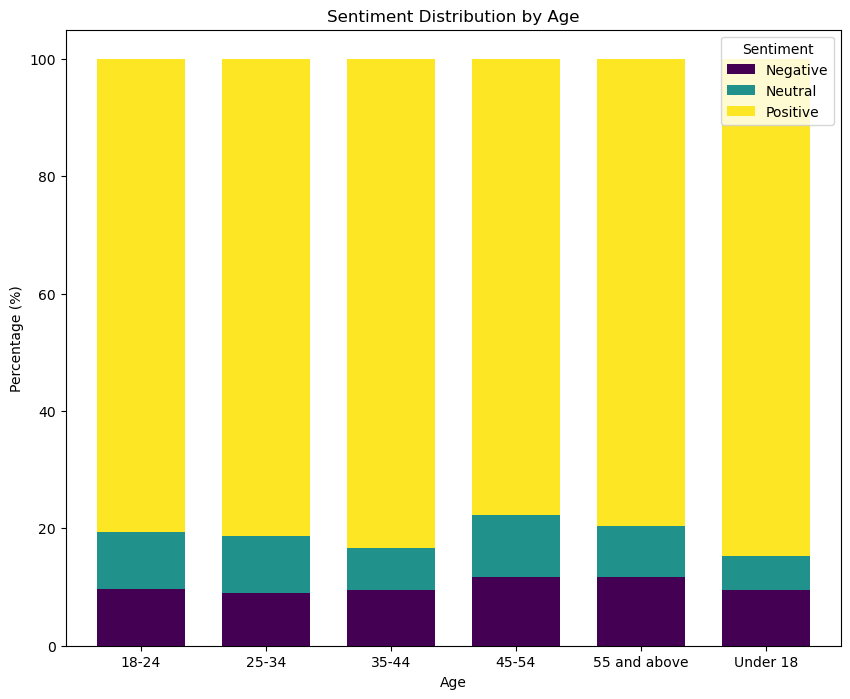

In [305]:
age_group_sentiment = df13.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Amazfit)[Sales Analysis].png")
plt.show()


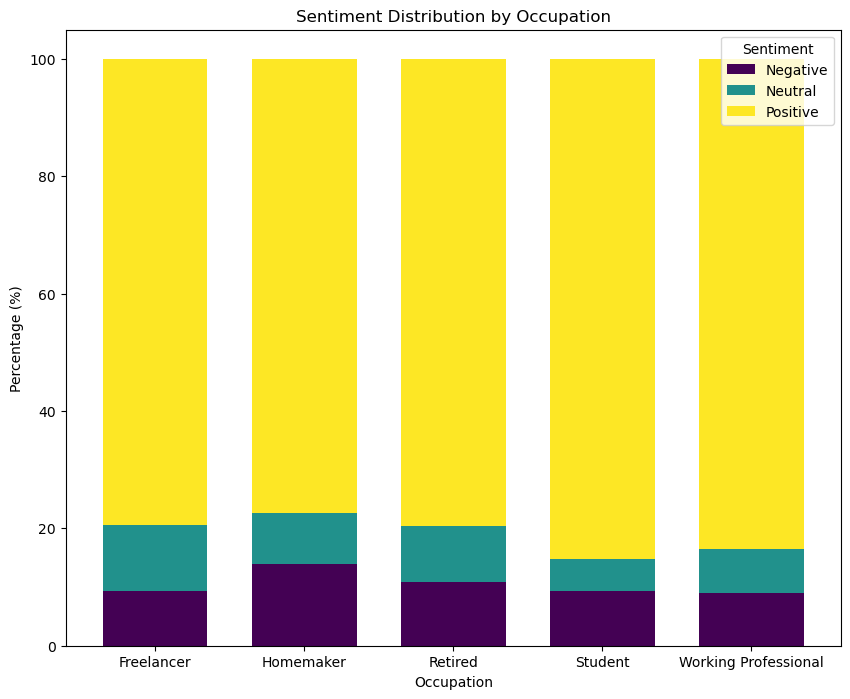

In [307]:
occupation_sentiment = df13.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Amazfit)[Sales Analysis].png")
plt.show()


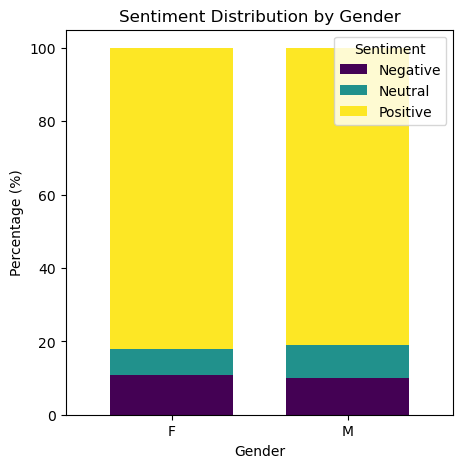

In [309]:
gender_sentiment = df13.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Amazfit)[Sales Analysis].png")
plt.show()


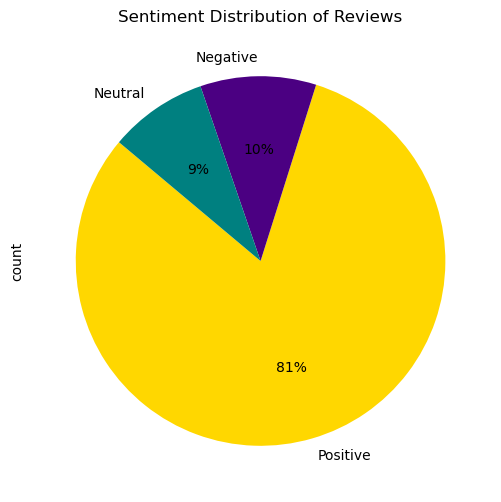

In [311]:
sentiment_counts = df13["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Amazfit)[Sentiment Analysis].png")
plt.show()

In [315]:
df14 = pd.read_csv("C:\\Users\\tanwa\\Downloads\\Colab Notebooks-20241019T120126Z-001\\Colab Notebooks\\Trend Analysis\\df14.csv")
pd.DataFrame(df14)

,Reviews for Fossil,Age,Gender,Location,Occupation,Month,Year,Quarter
0,I can say it's a well built good looking watch...,25-34,M,"Hyderabad, Telangana",Working Professional,February,2024,Q1
1,Its a good looking watch with all features tha...,55 and above,M,"New Delhi, Delhi",Retired,May,2021,Q2
2,Pretty decent watch! Good for function & party...,35-44,M,"New Delhi, Delhi",Working Professional,October,2021,Q4
3,i m using this product last 4 months. after re...,25-34,M,"Baleshwar, Gujarat",Working Professional,December,2024,Q4
4,Watch is beautiful and elegant. Run hours is a...,Under 18,M,"Gurugram, Haryana",Student,February,2020,Q1
...,...,...,...,...,...,...,...,...
436,After use of more than 1 year watch is OK... l...,Under 18,M,"Amritsar, Punjab",Student,March,2021,Q1
437,Never ever buy any fossil smart product. Waste...,25-34,F,"Gwalior, Madhya Pradesh",Homemaker,June,2021,Q2
438,Loved the watch,55 and above,M,"Thane, Maharashtra",Retired,November,2020,Q4
439,Overall a great buy but battery is so poor nd ...,55 and above,M,"New Delhi, Delhi",Retired,October,2024,Q4


In [319]:
import matplotlib.pyplot as plt
sentiment_column = "Sentiment" 
location_column = "Location"
age_column = "Age"
gender_column = "Gender"
occupation_column = "Occupation"

sentiment_weights = {"Positive": 1, "Neutral": 0.5, "Negative": 0}
df14.columns = df14.columns.str.strip()
review_column = "Reviews for Fossil"
def analyze_sentiment(review):
    analysis = TextBlob(str(review))  
    polarity = analysis.sentiment.polarity
    sentiment = "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"
    return pd.Series([polarity, sentiment])  
    
df14[['Polarity', 'Sentiment']] = df14[review_column].apply(analyze_sentiment)
print(df14.head())


                                  Reviews for Fossil           Age Gender  \
0  I can say it's a well built good looking watch...         25-34      M   
1  Its a good looking watch with all features tha...  55 and above      M   
2  Pretty decent watch! Good for function & party...         35-44      M   
3  i m using this product last 4 months. after re...         25-34      M   
4  Watch is beautiful and elegant. Run hours is a...      Under 18      M   

                Location            Occupation     Month  Year Quarter  \
0   Hyderabad, Telangana  Working Professional  February  2024      Q1   
1       New Delhi, Delhi               Retired       May  2021      Q2   
2       New Delhi, Delhi  Working Professional   October  2021      Q4   
3     Baleshwar, Gujarat  Working Professional  December  2024      Q4   
4      Gurugram, Haryana               Student  February  2020      Q1   

   Polarity Sentiment  
0  0.435417  Positive  
1  0.243750  Positive  
2  0.333333  Positiv

In [321]:
def extract_state(location):
    try:
        return location.split(",")[-1].strip()  
    except:
        return None  

df14['state'] = df14['Location'].astype(str).apply(extract_state)
df14

,Reviews for Fossil,Age,Gender,Location,Occupation,Month,Year,Quarter,Polarity,Sentiment,state
0,I can say it's a well built good looking watch...,25-34,M,"Hyderabad, Telangana",Working Professional,February,2024,Q1,0.435417,Positive,Telangana
1,Its a good looking watch with all features tha...,55 and above,M,"New Delhi, Delhi",Retired,May,2021,Q2,0.243750,Positive,Delhi
2,Pretty decent watch! Good for function & party...,35-44,M,"New Delhi, Delhi",Working Professional,October,2021,Q4,0.333333,Positive,Delhi
3,i m using this product last 4 months. after re...,25-34,M,"Baleshwar, Gujarat",Working Professional,December,2024,Q4,0.392857,Positive,Gujarat
4,Watch is beautiful and elegant. Run hours is a...,Under 18,M,"Gurugram, Haryana",Student,February,2020,Q1,0.118750,Positive,Haryana
...,...,...,...,...,...,...,...,...,...,...,...
436,After use of more than 1 year watch is OK... l...,Under 18,M,"Amritsar, Punjab",Student,March,2021,Q1,0.500000,Positive,Punjab
437,Never ever buy any fossil smart product. Waste...,25-34,F,"Gwalior, Madhya Pradesh",Homemaker,June,2021,Q2,0.007143,Positive,Madhya Pradesh
438,Loved the watch,55 and above,M,"Thane, Maharashtra",Retired,November,2020,Q4,0.700000,Positive,Maharashtra
439,Overall a great buy but battery is so poor nd ...,55 and above,M,"New Delhi, Delhi",Retired,October,2024,Q4,0.380000,Positive,Delhi


In [325]:
df14 = df14[df14['state'] != 'Maharshtra']

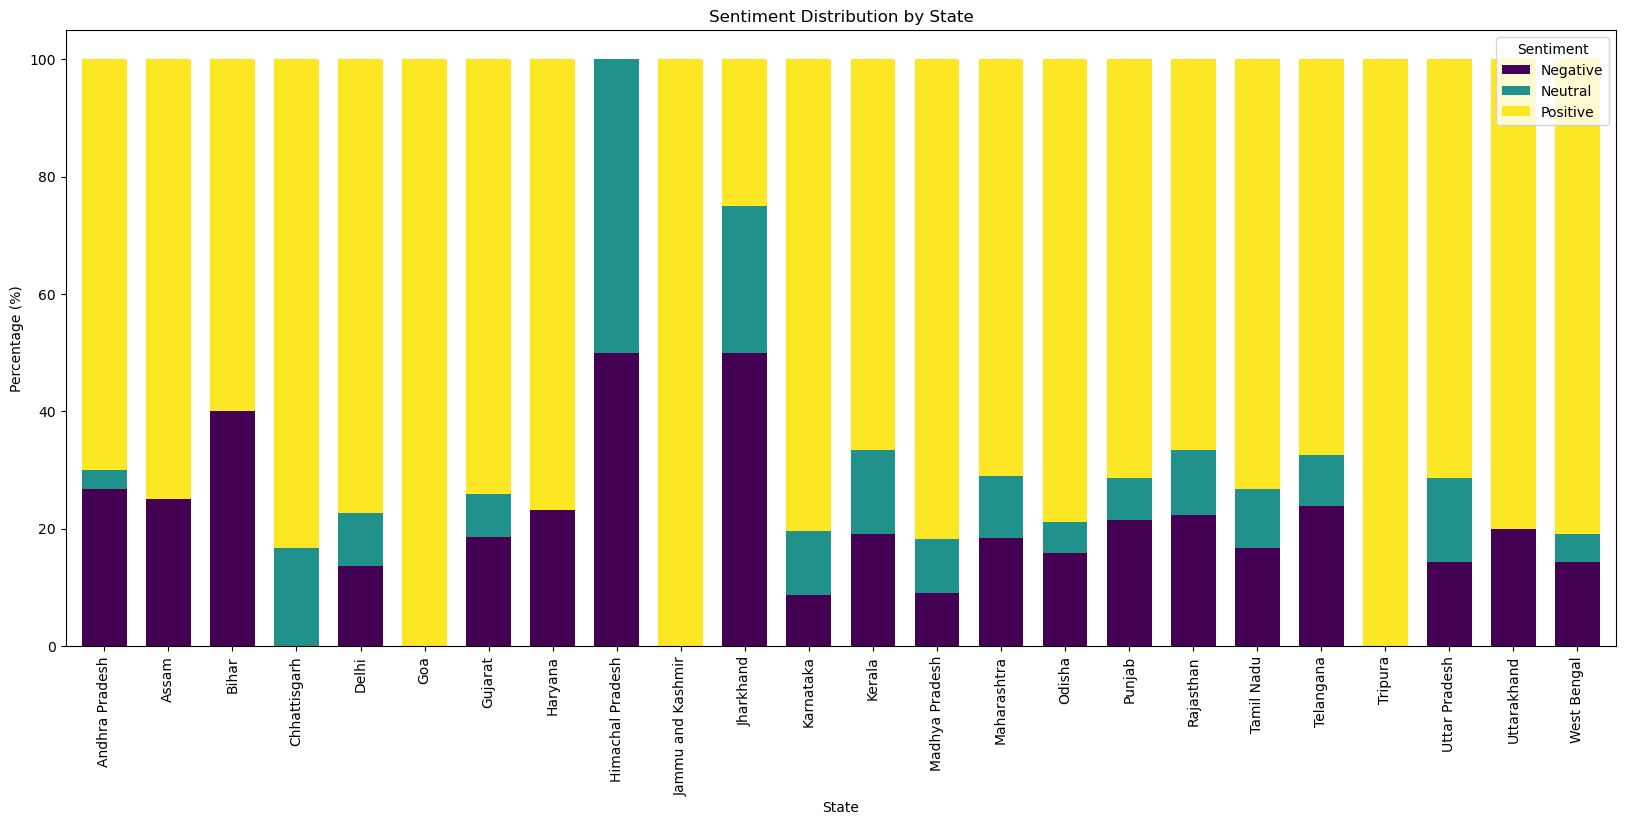

In [327]:
state_column = "state"
# 1. Sentiment distribution by location
state_sentiment = df14.groupby('state')['Sentiment'].value_counts().unstack(fill_value=0)
state_sentiment['Total'] = state_sentiment.sum(axis=1)
sentiment_counts_norm1 = state_sentiment.div(state_sentiment['Total'], axis=0) * 100

# Visualize the results
sentiment_counts_norm1.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis', figsize=(20, 8),width= 0.7)
plt.title("Sentiment Distribution by State")
plt.xlabel("State")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=90)
plt.savefig("sentiment_sales_by_state(Fossil)[Sales Analysis].png")
plt.show()

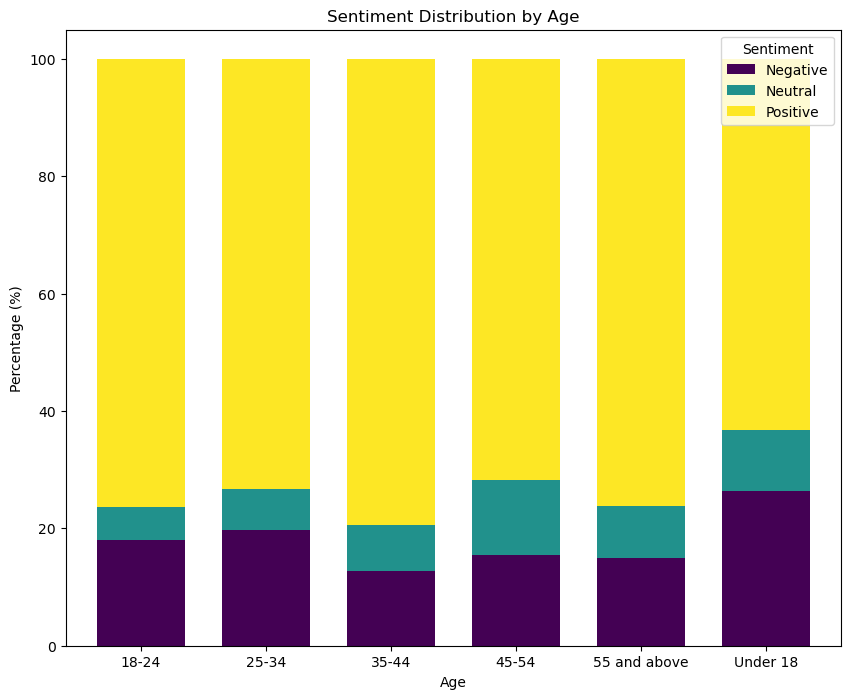

In [329]:
age_group_sentiment = df14.groupby(age_column)['Sentiment'].value_counts().unstack(fill_value=0)
age_group_sentiment['Total'] = age_group_sentiment.sum(axis=1)
sentiment_counts_norm2 = age_group_sentiment.div(age_group_sentiment['Total'], axis=0) * 100

sentiment_counts_norm2.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Age")
plt.xlabel("Age")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment__sales_by_age(Fossil)[Sales Analysis].png")
plt.show()


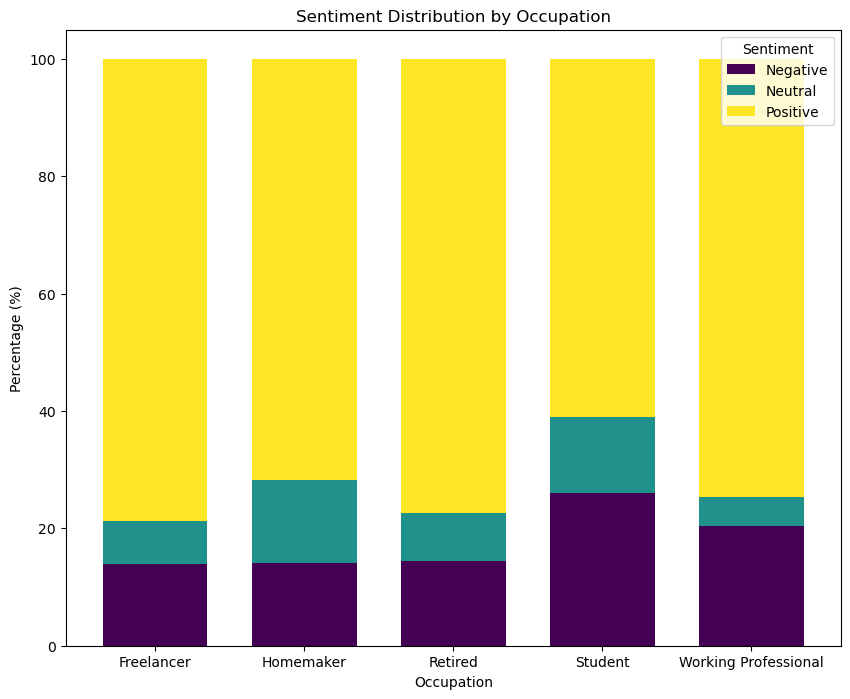

In [331]:
occupation_sentiment = df14.groupby(occupation_column)['Sentiment'].value_counts().unstack(fill_value=0)
occupation_sentiment['Total'] = occupation_sentiment.sum(axis=1)
sentiment_counts_norm3 = occupation_sentiment.div(occupation_sentiment['Total'], axis=0) * 100

sentiment_counts_norm3.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(10,8),width= 0.7)
plt.title("Sentiment Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_occupation(Fossil)[Sales Analysis].png")
plt.show()


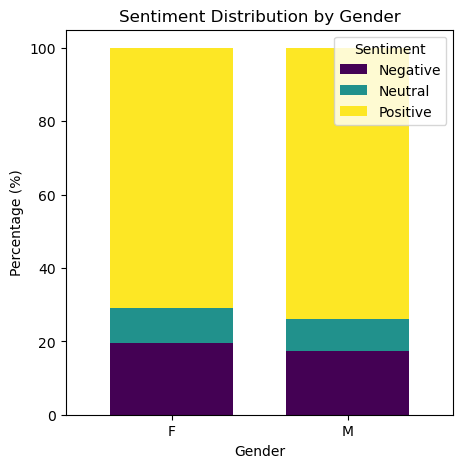

In [333]:
gender_sentiment = df14.groupby(gender_column)['Sentiment'].value_counts().unstack(fill_value=0)
gender_sentiment['Total'] = gender_sentiment.sum(axis=1)
sentiment_counts_norm4 = gender_sentiment.div(gender_sentiment['Total'], axis=0) * 100

sentiment_counts_norm4.drop(columns=['Total']).plot(kind='bar',stacked=True, colormap='viridis',figsize=(5,5),width= 0.7)
plt.title("Sentiment Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Sentiment")
plt.xticks(rotation=0)
plt.savefig("sentiment_sales_by_gender(Fossil)[Sales Analysis].png")
plt.show()


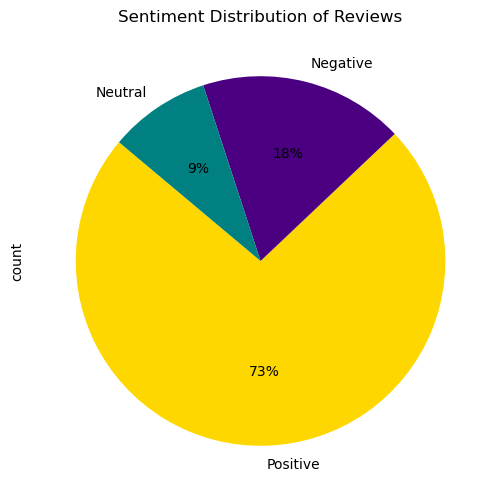

In [335]:
sentiment_counts = df14["Sentiment"].value_counts()
plt.figure(figsize=(6, 6))
sentiment_counts.plot(kind='pie', autopct='%.0f%%', colors= ['#FFD700','#4B0082','#008080' ], startangle=140)
plt.title("Sentiment Distribution of Reviews")
plt.savefig("overall_sentiment(Fossil)[Sentiment Analysis].png")
plt.show()